In [1]:
library(tidyverse); library(zoo)
csv <- "../processed/cariaco_monthly_euphotic_dynamic.csv"
ERA_OF <- function(y) ifelse(y<2005,"pre",ifelse(y<2014,"post","recovery"))
DPM <- c(31,28,31,30,31,30,31,31,30,31,30,31); MIDDOY <- cumsum(DPM)-DPM/2

df <- read.csv(csv) %>% mutate(date=as.Date(date), year=as.integer(format(date,"%Y")),
              mo=as.integer(format(date,"%m")), era=ERA_OF(year),
              J=FN_mmolN_m2_d/depth_cutoff)              # Stock volumetric supply

clim <- function(d,col,stat){ f<-match.fun(stat)            # replicate _monthly_mean
  v<-sapply(1:12,function(m){x<-d[[col]][d$mo==m]; x<-x[is.finite(x)]; if(length(x)) f(x) else NA_real_})
  as.numeric(na.approx(v,1:12,rule=2)) }
fourier <- function(monthly,n,per=365){                     # replicate _build_fourier_func
  A<-cbind(1,do.call(cbind,lapply(1:n,function(k)cbind(cos(2*pi*k*MIDDOY/per),sin(2*pi*k*MIDDOY/per)))))
  co<-qr.solve(A,monthly)
  function(t){B<-cbind(1,do.call(cbind,lapply(1:n,function(k)cbind(cos(2*pi*k*t/per),sin(2*pi*k*t/per)))));pmax(as.numeric(B%*%co),0)} }

post <- df %>% filter(era=="post"); tt <- 0:364
fn_m<-clim(post,"FN_mmolN_m2_d","mean"); de_m<-clim(post,"depth_cutoff","mean")
fn2<-fourier(fn_m,2); de2<-fourier(de_m,2); fn3<-fourier(fn_m,3); de3<-fourier(de_m,3)

tab <- tibble(month=month.abb,
  FN_mean=round(fn_m,3), FN_median=round(clim(post,"FN_mmolN_m2_d","median"),3),
  de_mean=round(de_m,2),
  J_mean=round(clim(post,"J","mean"),4), J_median=round(clim(post,"J","median"),4),
  J_F2=round(fn2(MIDDOY)/de2(MIDDOY),4), J_F3=round(fn3(MIDDOY)/de3(MIDDOY),4))
cat("=== POST: monthly supply climatology vs what the ODE is fed (Fourier J=FN/de) ===\n")
print(as.data.frame(tab), row.names=FALSE)

pk <- function(f){d<-tt[which.max(f(tt))]; month.abb[as.integer(format(as.Date(d,origin="2000-12-31"),"%m"))]}
cat(sprintf("\nPeak month of J:  clim-mean=%s | Fourier3h=%s | Fourier2h=%s\n",
            month.abb[which.max(tab$J_mean)], pk(function(t)fn3(t)/de3(t)), pk(function(t)fn2(t)/de2(t))))
rj<-function(c){x<-post[[c]][post$mo==1];x[is.finite(x)]}
cat(sprintf("Jan retention (Fourier3h@Jan / raw-Jan-mean):  FN=%.2f  de=%.2f  J=%.2f\n",
  fn3(MIDDOY[1])/mean(rj("FN_mmolN_m2_d")), de3(MIDDOY[1])/mean(rj("depth_cutoff")),
  (fn3(MIDDOY[1])/de3(MIDDOY[1]))/mean(rj("J"))))
cat(sprintf("Jan vs annual-max of fed J:  Fourier3h=%.2f  Fourier2h=%.2f   (1.0 = Jan IS the fed peak)\n",
  (fn3(MIDDOY[1])/de3(MIDDOY[1]))/max(fn3(tt)/de3(tt)), (fn2(MIDDOY[1])/de2(MIDDOY[1]))/max(fn2(tt)/de2(tt))))
cat(sprintf("Sampling skew at Jan (mean/median):  FN=%.2f  J=%.2f  (>1 = few high cruises lift the mean)\n",
  tab$FN_mean[1]/tab$FN_median[1], tab$J_mean[1]/tab$J_median[1]))

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attache Paket: ‘zoo’


Die folgenden Objekte sind maskiert von ‘package:base’:

    as.Date, as.Date.numeric




=== POST: monthly supply climatology vs what the ODE is fed (Fourier J=FN/de) ===
 month FN_mean FN_median de_mean J_mean J_median   J_F2   J_F3
   Jan   3.136     2.759   36.25 0.0936   0.0740 0.0811 0.0810
   Feb   4.802     3.690   33.51 0.1726   0.1503 0.1150 0.1277
   Mar   3.307     1.970   40.57 0.1437   0.0464 0.1024 0.1033
   Apr   2.932     2.444   44.48 0.0725   0.0567 0.0637 0.0550
   May   1.866     1.549   49.95 0.0375   0.0319 0.0367 0.0364
   Jun   1.601     1.440   52.88 0.0292   0.0249 0.0305 0.0377
   Jul   2.204     1.787   50.55 0.0448   0.0352 0.0375 0.0377
   Aug   1.745     1.583   49.79 0.0378   0.0298 0.0411 0.0337
   Sep   1.364     1.365   54.31 0.0254   0.0249 0.0308 0.0308
   Oct   1.539     1.625   56.39 0.0273   0.0300 0.0168 0.0233
   Nov   0.753     0.632   48.19 0.0159   0.0155 0.0151 0.0150
   Dec   1.276     1.385   54.14 0.0241   0.0237 0.0363 0.0285

Peak month of J:  clim-mean=Feb | Fourier3h=Feb | Fourier2h=Feb
Jan retention (Fourier3h@Jan / raw

In [2]:
prov <- df %>% filter(era=="post", mo %in% 1:2) %>%
  transmute(date, mo, FN=FN_mmolN_m2_d, PP=PP_mgC_m2_d, depth_cutoff, cutoff_source,
            NO3=NO3_mmolN, micro_mmolN, TChla_reconstructed) %>% arrange(date)
print(as.data.frame(prov), row.names=FALSE)
cat("\ndepth_cutoff provenance (post Jan/Feb):\n"); print(table(prov$cutoff_source, useNA="ifany"))
cat(sprintf("F_N present (=PP-measured) in %d/%d post Jan-Feb months; depth_cutoff observed in %d\n",
  sum(is.finite(prov$FN)), nrow(prov), sum(prov$cutoff_source=="observed", na.rm=TRUE)))

       date mo       FN        PP depth_cutoff      cutoff_source       NO3
 2005-01-01  1 2.486155 1147.5513     40.96792 isotherm_chl_model 0.8629644
 2005-02-01  2       NA        NA           NA      no_prediction        NA
 2006-01-01  1 2.758890 1176.3278     37.30000           observed 1.4192919
 2006-02-01  2 6.869445 2785.4048     29.40000           observed 0.1276963
 2007-01-01  1       NA        NA           NA      no_prediction        NA
 2007-02-01  2 7.791667 2981.7608     23.70000           observed 1.2515906
 2008-01-01  1 1.473547  709.5715     48.48711 isotherm_chl_model 1.4598558
 2008-02-01  2 3.505208 1530.9295     36.23659 isotherm_chl_model 1.0002588
 2009-01-01  1 4.035741 1867.0751     29.47845 isotherm_chl_model 0.3133842
 2009-02-01  2       NA 1200.1634     47.00591 isotherm_chl_model 5.1867236
 2010-01-01  1       NA        NA           NA      no_prediction        NA
 2010-02-01  2       NA        NA           NA      no_prediction        NA
 2011-01-01 

In [3]:
hp  <- readRDS("../processed/HPLC_depth_profiles.rds")
cut <- df %>% transmute(time_month=format(date,"%m-%Y"), depth_cutoff)
fuco <- hp %>% mutate(time_month=format(date,"%m-%Y")) %>% left_join(cut, by="time_month") %>%
  filter(!is.na(depth_cutoff), depth>=0, depth<=depth_cutoff) %>%
  group_by(date) %>% summarise(Fuco=mean(Fuco,na.rm=TRUE), Hex=mean(Hex_fuco,na.rm=TRUE),
                               Zea=mean(Zea,na.rm=TRUE), .groups="drop") %>%
  mutate(year=as.integer(format(date,"%Y")), mo=as.integer(format(date,"%m")), era=ERA_OF(year),
         Fuco_frac=Fuco/(Fuco+Hex+Zea))           # fucoxanthin share = diatom dominance

cat("=== POST winter (Jan-Mar): per-cruise size + diatom-pigment signature ===\n")
df %>% filter(era=="post", mo %in% 1:3) %>%
  transmute(date, mo, micro_mmolN, sumP=micro_mmolN+nano_mmolN+pico_mmolN,
            size_centroid, nbss_slope, PhaeoChl_ratio) %>%
  left_join(fuco %>% select(date, Fuco, Fuco_frac), by="date") %>%
  arrange(date) %>% as.data.frame() %>% print(row.names=FALSE)

=== POST winter (Jan-Mar): per-cruise size + diatom-pigment signature ===
       date mo micro_mmolN      sumP size_centroid nbss_slope PhaeoChl_ratio
 2005-01-01  1          NA        NA            NA         NA      0.8088659
 2005-02-01  2          NA        NA            NA         NA             NA
 2005-03-01  3          NA        NA            NA         NA             NA
 2006-01-01  1          NA        NA            NA         NA      0.8358789
 2006-02-01  2          NA        NA            NA         NA      0.5628928
 2006-03-01  3          NA        NA            NA         NA      0.9216988
 2007-01-01  1          NA        NA            NA         NA             NA
 2007-02-01  2          NA        NA            NA         NA      0.7433730
 2007-03-01  3          NA        NA            NA         NA      1.0337163
 2008-01-01  1  0.15852928 0.3693530     0.8926799 -0.9822503      0.9839254
 2008-02-01  2  0.14731545 1.0506740     0.4489741 -1.0906545      0.7803439
 2

In [4]:
# (a) is silicate even in the raw data?
nk <- readRDS("../processed/Niskin_cleaned.rds")
si <- grep("sil|sio|^si$|si_|silic", names(nk), ignore.case=TRUE, value=TRUE)
cat("Niskin_cleaned columns:\n"); print(names(nk))
cat(sprintf("\nSilicate-like column(s): %s\n", if(length(si)) paste(si,collapse=", ") else "NONE — Si not in obs product"))

# (b) what differs in POST winters vs pre/recovery winters (DJF)
cat("\n=== DJF winter contrast by era (medians) ===\n")
df %>% filter(mo %in% c(12,1,2)) %>% group_by(era) %>%
  summarise(n=n(), FN=median(FN_mmolN_m2_d,na.rm=TRUE), de=median(depth_cutoff,na.rm=TRUE),
            J=median(J,na.rm=TRUE), MLD=median(MLD,na.rm=TRUE), temp50=median(temp_50m,na.rm=TRUE),
            micro=median(micro_mmolN,na.rm=TRUE), centroid=median(size_centroid,na.rm=TRUE),
            .groups="drop") %>% as.data.frame() %>% print(row.names=FALSE)

# (c) photoperiod at 10.5 N (pure solar geometry, not a climate index)
lat<-10.5*pi/180; dl<-function(d){de<-23.45*pi/180*sin(2*pi*(284+d)/365); 24/pi*acos(pmax(-1,pmin(1,-tan(lat)*tan(de))))}
cat(sprintf("\nDaylength @10.5N: Jan15=%.2f h | annual range [%.2f, %.2f] (span %.2f h); Jan is near the annual MIN\n",
  dl(15), min(dl(1:365)), max(dl(1:365)), diff(range(dl(1:365)))))

Niskin_cleaned columns:
  [1] "Cruise_number"               "Cruise_ID_1"                
  [3] "Cruise_ID_2"                 "Leg"                        
  [5] "Day"                         "Month"                      
  [7] "Year"                        "Latitude"                   
  [9] "Longitude"                   "Hydro_cast_no"              
 [11] "Depth_target"                "Depth_real"                 
 [13] "O2_ml_L"                     "q_O2_ml_L"                  
 [15] "O2_umol_kg"                  "q_O2_umol_kg"               
 [17] "NO3_UDO"                     "q_NO3_UDO"                  
 [19] "PO4_UDO"                     "q_PO4_UDO"                  
 [21] "SiO4_UDO"                    "q_SiO4_UDO"                 
 [23] "NH4_USF"                     "q_NH4_USF"                  
 [25] "NO2_USF"                     "q_NO2_USF"                  
 [27] "NO3_NO2_USF"                 "q_NO3_NO3_USF"              
 [29] "PO4_USF"                     "q_PO4_USF"     


=== POST Jan/Feb individual cruises — is the large-cell signal one outlier? ===
       date mo fr_micro fr_pico sumP  mcs depth_cutoff      cutoff_source
 2008-01-01  1     0.43    0.34 0.37  7.8         48.5 isotherm_chl_model
 2009-01-01  1     0.66    0.20 1.07 18.1         29.5 isotherm_chl_model
 2011-01-01  1     0.83    0.10 1.79 33.9         31.6 isotherm_chl_model
 2012-01-01  1     0.90    0.05 1.82 44.7         29.7           observed
 2008-02-01  2     0.14    0.49 1.05  2.8         36.2 isotherm_chl_model
 2009-02-01  2     0.35    0.53 0.61  4.1         47.0 isotherm_chl_model
 2011-02-01  2     0.88    0.05 1.52 42.7         24.5 isotherm_chl_model

=== POST by month: coverage + mean-vs-median (outlier leverage) ===
 mo n n_interpEuZ micro_mean micro_med sumP_mean sumP_med
  1 4           3       0.70      0.74      1.26     1.43
  2 3           3       0.46      0.35      1.06     1.05
  3 5           4       0.27      0.25      0.63     0.55
  4 5           4       0.

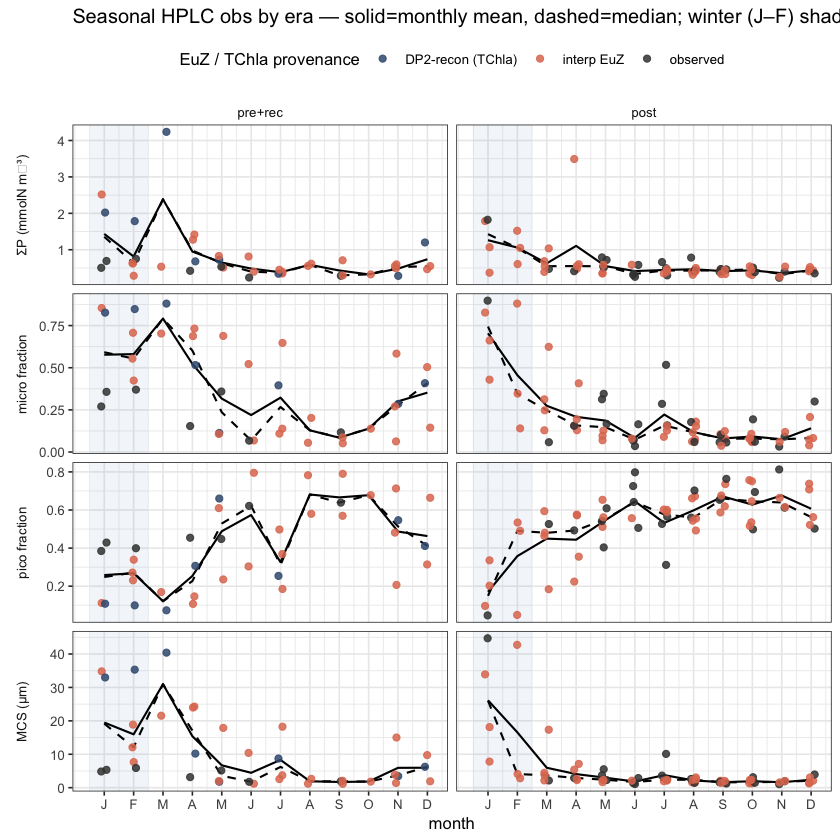

In [5]:
library(tidyverse)
csv <- "../processed/cariaco_monthly_euphotic_dynamic.csv"
ERA_OF <- function(y) ifelse(y<2005,"pre",ifelse(y<2014,"post","recovery"))
GEOM <- c(pico=0.63, nano=6.3, micro=63)            # Sieburth geomeans (pico,nano,micro)

d <- read.csv(csv) %>%
  mutate(date=as.Date(date), year=as.integer(format(date,"%Y")), mo=as.integer(format(date,"%m")),
         era=factor(ifelse(ERA_OF(year)=="post","post","pre+rec"), levels=c("pre+rec","post")),
         sumP = micro_mmolN + nano_mmolN + pico_mmolN) %>%
  filter(is.finite(sumP), sumP>0) %>%                # months with HPLC absolute biomass (n~103)
  mutate(fr_micro=micro_mmolN/sumP, fr_nano=nano_mmolN/sumP, fr_pico=pico_mmolN/sumP,
         mcs = 10^(fr_pico*log10(GEOM["pico"]) + fr_nano*log10(GEOM["nano"]) + fr_micro*log10(GEOM["micro"])),
         prov = case_when(TChla_reconstructed %in% c(TRUE,"TRUE") ~ "DP2-recon (TChla)",
                          cutoff_source=="isotherm_chl_model"     ~ "interp EuZ",
                          cutoff_source=="observed"               ~ "observed",
                          TRUE                                    ~ "other"))

long <- d %>% select(date, mo, era, prov, sumP, fr_micro, fr_pico, mcs) %>%
  pivot_longer(c(sumP, fr_micro, fr_pico, mcs), names_to="metric", values_to="val") %>%
  mutate(metric=factor(recode(metric, sumP="ΣP (mmolN m⁻³)", fr_micro="micro fraction",
                              fr_pico="pico fraction", mcs="MCS (µm)"),
                       levels=c("ΣP (mmolN m⁻³)","micro fraction","pico fraction","MCS (µm)")))

prov_cols <- c(observed="grey25", `interp EuZ`="#E07A5F", `DP2-recon (TChla)`="#3D5A80", other="grey70")

print(ggplot(long, aes(mo, val)) +
  annotate("rect", xmin=0.5, xmax=2.5, ymin=-Inf, ymax=Inf, fill="steelblue", alpha=0.07) +  # winter J-F
  stat_summary(aes(group=1), fun=mean,   geom="line", colour="black", linewidth=0.6) +
  stat_summary(aes(group=1), fun=median, geom="line", colour="black", linewidth=0.6, linetype="dashed") +
  geom_point(aes(colour=prov), position=position_jitter(width=0.12, height=0), size=1.7, alpha=0.85) +
  scale_colour_manual(values=prov_cols, name="EuZ / TChla provenance") +
  facet_grid(metric ~ era, scales="free_y", switch="y") +
  scale_x_continuous(breaks=1:12, labels=c("J","F","M","A","M","J","J","A","S","O","N","D")) +
  labs(x="month", y=NULL,
       title="Seasonal HPLC obs by era — solid=monthly mean, dashed=median; winter (J–F) shaded") +
  theme_bw(base_size=10) +
  theme(legend.position="top", strip.placement="outside", strip.background=element_blank()))

# --- diagnostics ---
cat("\n=== POST Jan/Feb individual cruises — is the large-cell signal one outlier? ===\n")
d %>% filter(era=="post", mo %in% 1:2) %>%
  transmute(date, mo, fr_micro=round(fr_micro,2), fr_pico=round(fr_pico,2),
            sumP=round(sumP,2), mcs=round(mcs,1), depth_cutoff=round(depth_cutoff,1),
            cutoff_source) %>% arrange(mo,date) %>% as.data.frame() %>% print(row.names=FALSE)

cat("\n=== POST by month: coverage + mean-vs-median (outlier leverage) ===\n")
d %>% filter(era=="post") %>% group_by(mo) %>%
  summarise(n=n(), n_interpEuZ=sum(prov=="interp EuZ"),
            micro_mean=round(mean(fr_micro),2), micro_med=round(median(fr_micro),2),
            sumP_mean=round(mean(sumP),2), sumP_med=round(median(sumP),2), .groups="drop") %>%
  as.data.frame() %>% print(row.names=FALSE)

cat("\n=== JANUARY contrast: pre+rec vs post ===\n")
d %>% filter(mo==1) %>% group_by(era) %>%
  summarise(n=n(), micro_mean=round(mean(fr_micro),2), micro_med=round(median(fr_micro),2),
            pico_mean=round(mean(fr_pico),2), pico_med=round(median(fr_pico),2),
            mcs_mean=round(mean(mcs),1), mcs_med=round(median(mcs),1), .groups="drop") %>%
  as.data.frame() %>% print(row.names=FALSE)

In [9]:
options(repr.plot.width = 14, repr.plot.height = 13, repr.plot.res = 150)

Warning message:
“Removed 284 rows containing missing values or values outside the scale range
(`geom_point()`).”


=== upwelling-extreme month per driver (FN/J = max; d_e/iso/T = min) ===
     era driver mean median F3
    post     FN    F      F  F
    post      J    F      F  F
    post     de    F      F  F
    post    iso    A      A  M
    post      T    A      A  M
 pre+rec     FN    F      F  F
 pre+rec      J    M      F  F
 pre+rec     de    J      M  F
 pre+rec    iso    M      M  M
 pre+rec      T    M      M  M


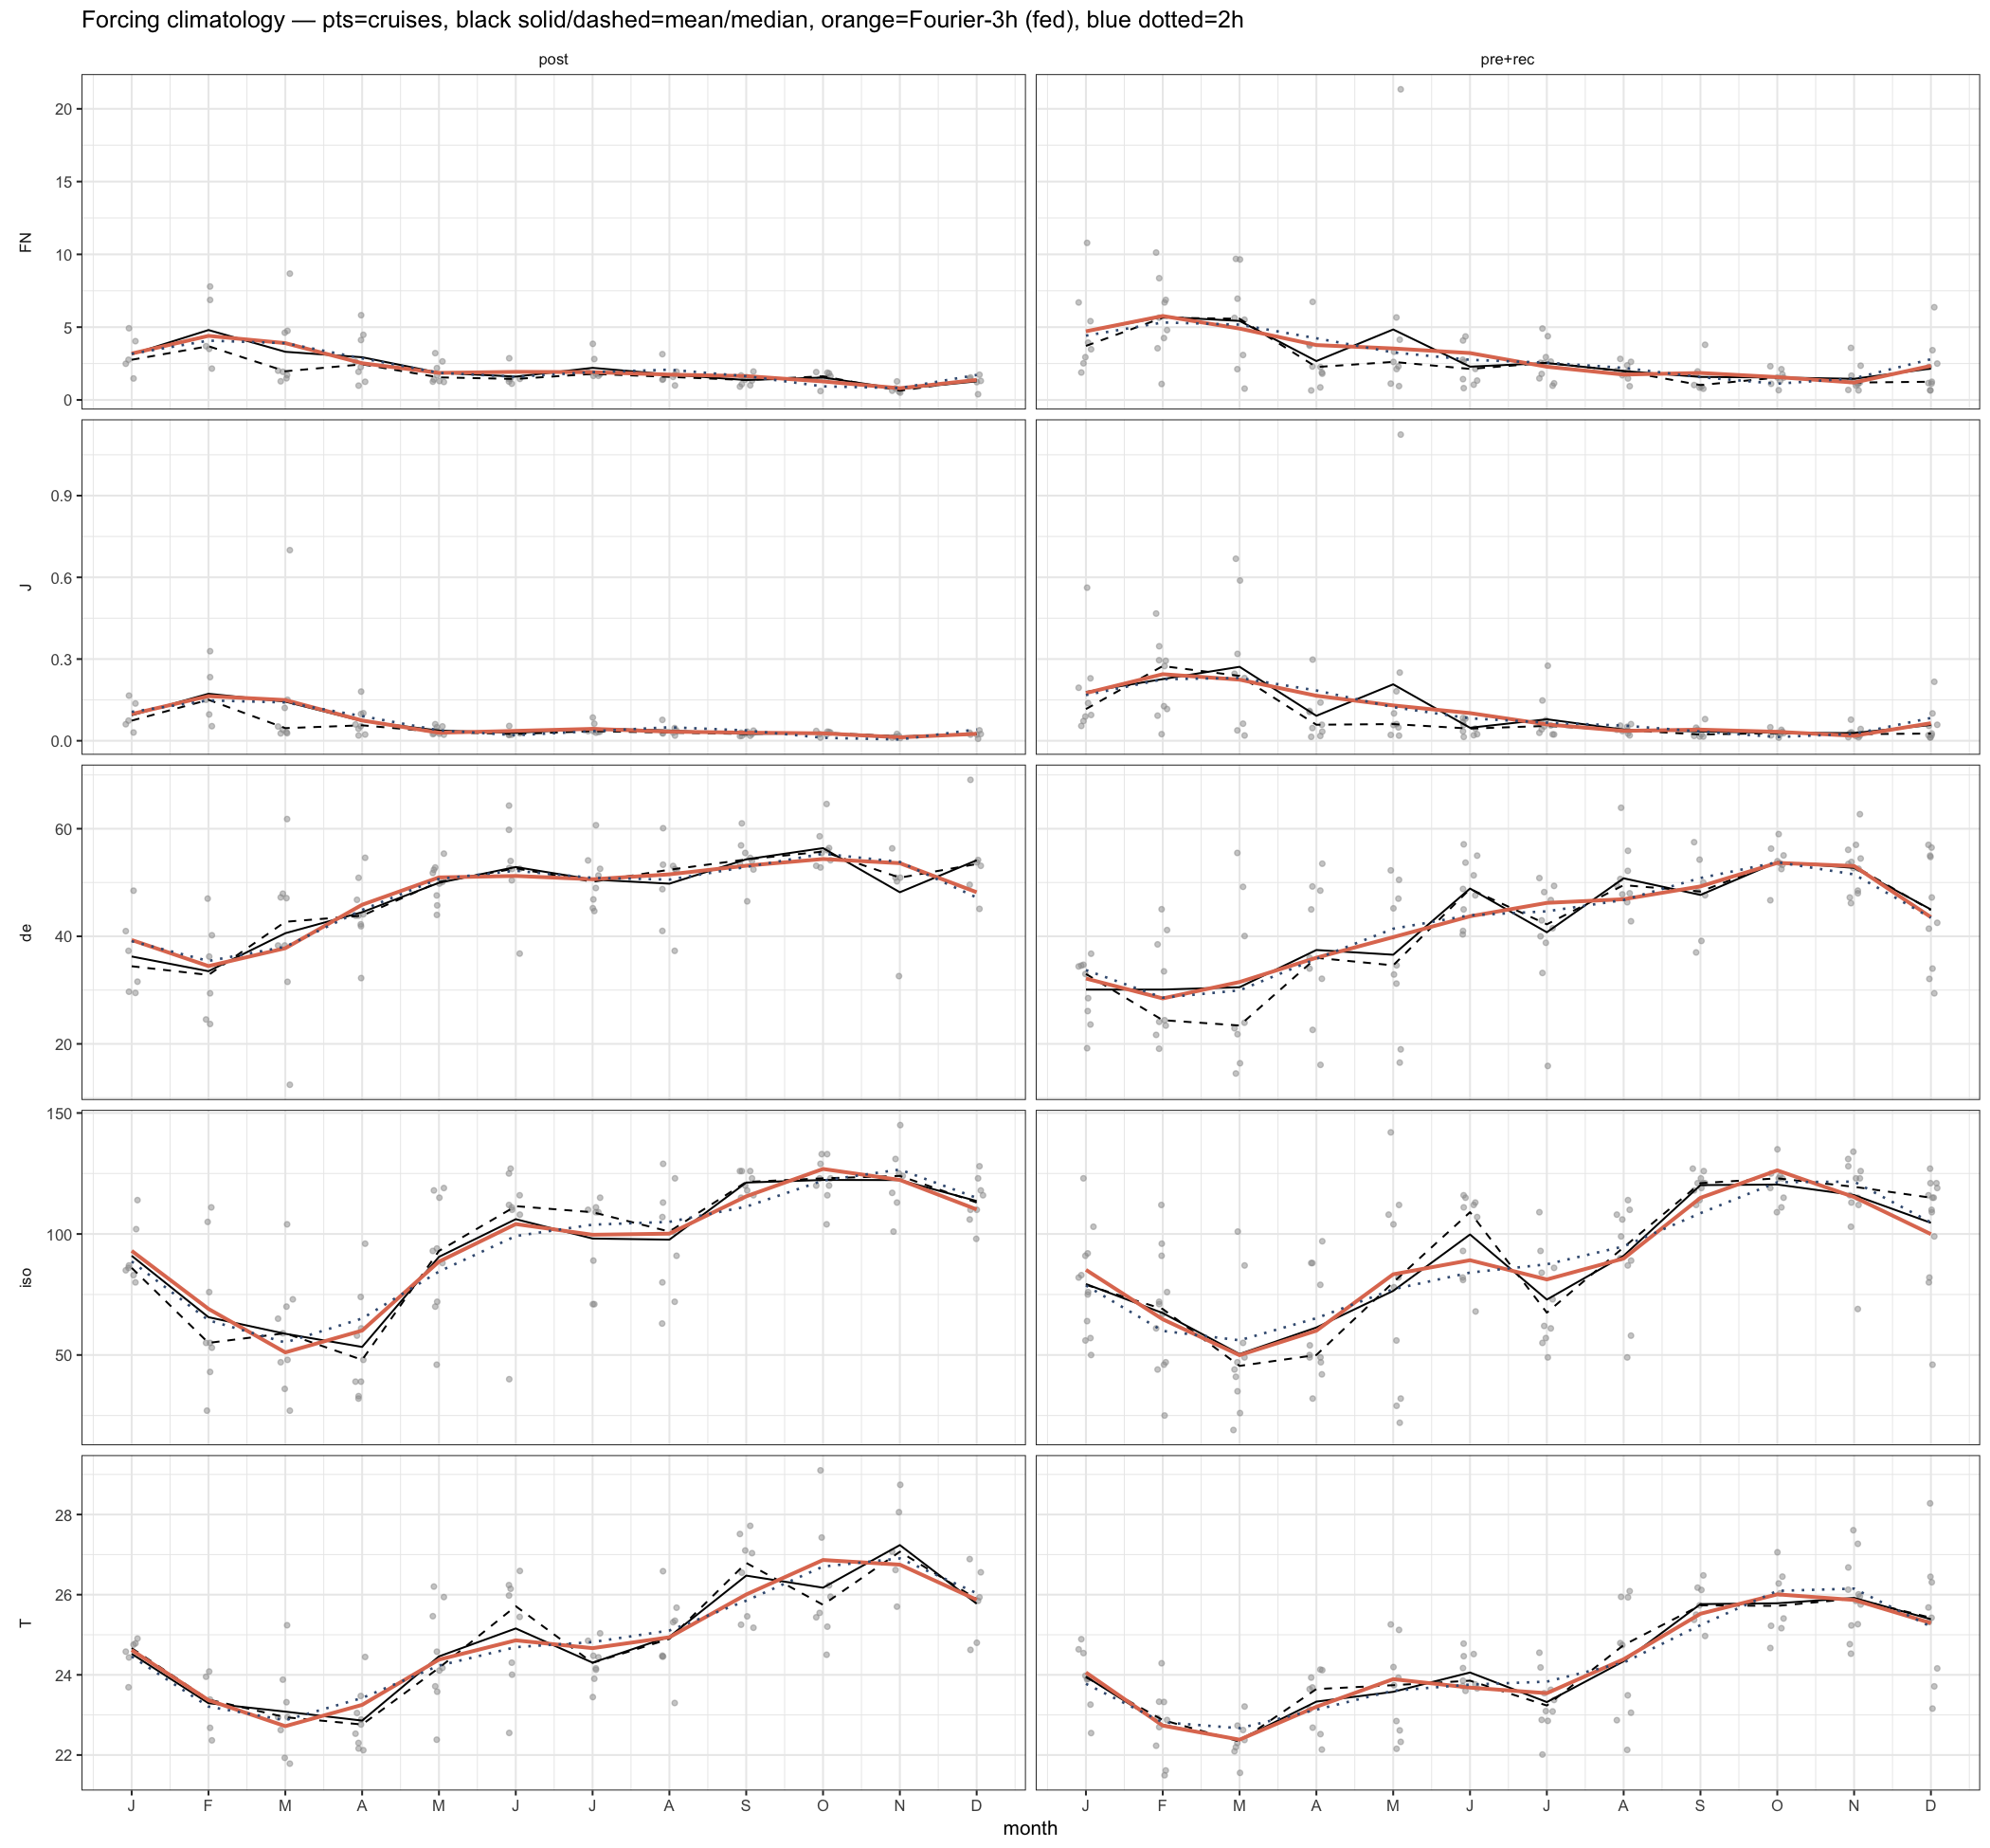

In [10]:
library(tidyverse); library(zoo)
csv <- "../processed/cariaco_monthly_euphotic_dynamic.csv"
ERA_OF <- function(y) ifelse(y<2005,"pre",ifelse(y<2014,"post","recovery"))
DPM <- c(31,28,31,30,31,30,31,31,30,31,30,31); MIDDOY <- cumsum(DPM)-DPM/2
MOABB <- c("J","F","M","A","M","J","J","A","S","O","N","D")

D <- read.csv(csv) %>% mutate(date=as.Date(date), year=as.integer(format(date,"%Y")),
       mo=as.integer(format(date,"%m")),
       era=factor(ifelse(ERA_OF(year)=="post","post","pre+rec"), levels=c("pre+rec","post")),
       J=FN_mmolN_m2_d/depth_cutoff, sumP=micro_mmolN+nano_mmolN+pico_mmolN,
       has_hplc=!is.na(micro_frac))

clim <- function(d,col,stat="mean"){ f<-match.fun(stat)
  v<-sapply(1:12,function(m){x<-d[[col]][d$mo==m];x<-x[is.finite(x)];if(length(x))f(x) else NA_real_})
  as.numeric(na.approx(v,1:12,rule=2)) }
fourier <- function(monthly,n,per=365){
  A<-cbind(1,do.call(cbind,lapply(1:n,function(k)cbind(cos(2*pi*k*MIDDOY/per),sin(2*pi*k*MIDDOY/per)))))
  co<-qr.solve(A,monthly); function(t){B<-cbind(1,do.call(cbind,lapply(1:n,function(k)cbind(cos(2*pi*k*t/per),sin(2*pi*k*t/per)))));pmax(as.numeric(B%*%co),0)} }

drivers <- c(FN="FN_mmolN_m2_d", de="depth_cutoff", T="Temp_C", iso="Isotherm_21", J="J")
drv_lvl <- c("FN","J","de","iso","T")
plotdat <- map_dfr(levels(D$era), function(e){ de<-D%>%filter(era==e)
  map_dfr(names(drivers), function(nm){ cm<-clim(de,drivers[nm])
    tibble(era=e, driver=nm, mo=1:12, mean=cm, median=clim(de,drivers[nm],"median"),
           F3=fourier(cm,3)(MIDDOY), F2=fourier(cm,2)(MIDDOY)) }) }) %>%
  mutate(driver=factor(driver,levels=drv_lvl))
pts <- D %>% select(era,mo,all_of(unname(drivers))) %>%
  pivot_longer(-c(era,mo),names_to="col",values_to="val") %>%
  mutate(driver=factor(names(drivers)[match(col,drivers)],levels=drv_lvl))

print(ggplot(plotdat,aes(mo)) +
  geom_point(data=pts,aes(y=val),colour="grey60",size=1,alpha=0.5,position=position_jitter(width=0.1,height=0))+
  geom_line(aes(y=mean),colour="black")+geom_line(aes(y=median),colour="black",linetype="dashed")+
  geom_line(aes(y=F3),colour="#E07A5F",linewidth=0.9)+geom_line(aes(y=F2),colour="#3D5A80",linewidth=0.6,linetype="dotted")+
  facet_grid(driver~era,scales="free_y",switch="y")+scale_x_continuous(breaks=1:12,labels=MOABB)+
  labs(x="month",y=NULL,title="Forcing climatology — pts=cruises, black solid/dashed=mean/median, orange=Fourier-3h (fed), blue dotted=2h")+
  theme_bw(base_size=10)+theme(strip.placement="outside",strip.background=element_blank()))

cat("=== upwelling-extreme month per driver (FN/J = max; d_e/iso/T = min) ===\n")
ext_mo <- function(v,dr) if(as.character(dr) %in% c("de","iso","T")) which.min(v) else which.max(v)
plotdat %>% group_by(era,driver) %>%
  summarise(mean=MOABB[ext_mo(mean,first(driver))], median=MOABB[ext_mo(median,first(driver))],
            F3=MOABB[ext_mo(F3,first(driver))], .groups="drop") %>% as.data.frame() %>% print(row.names=FALSE)

=== fed supply J=F_N/d_e: peak month + Jan/Feb + Jan-vs-peak ratio ===
     era         variant peak    Jan    Feb Jan_vs_peak
    post HPLC-coincident    F 0.0801 0.0996        0.80
    post      all-cruise    F 0.0810 0.1277        0.63
 pre+rec HPLC-coincident    F 0.1645 0.1761        0.93
 pre+rec      all-cruise    F 0.1466 0.2027        0.72


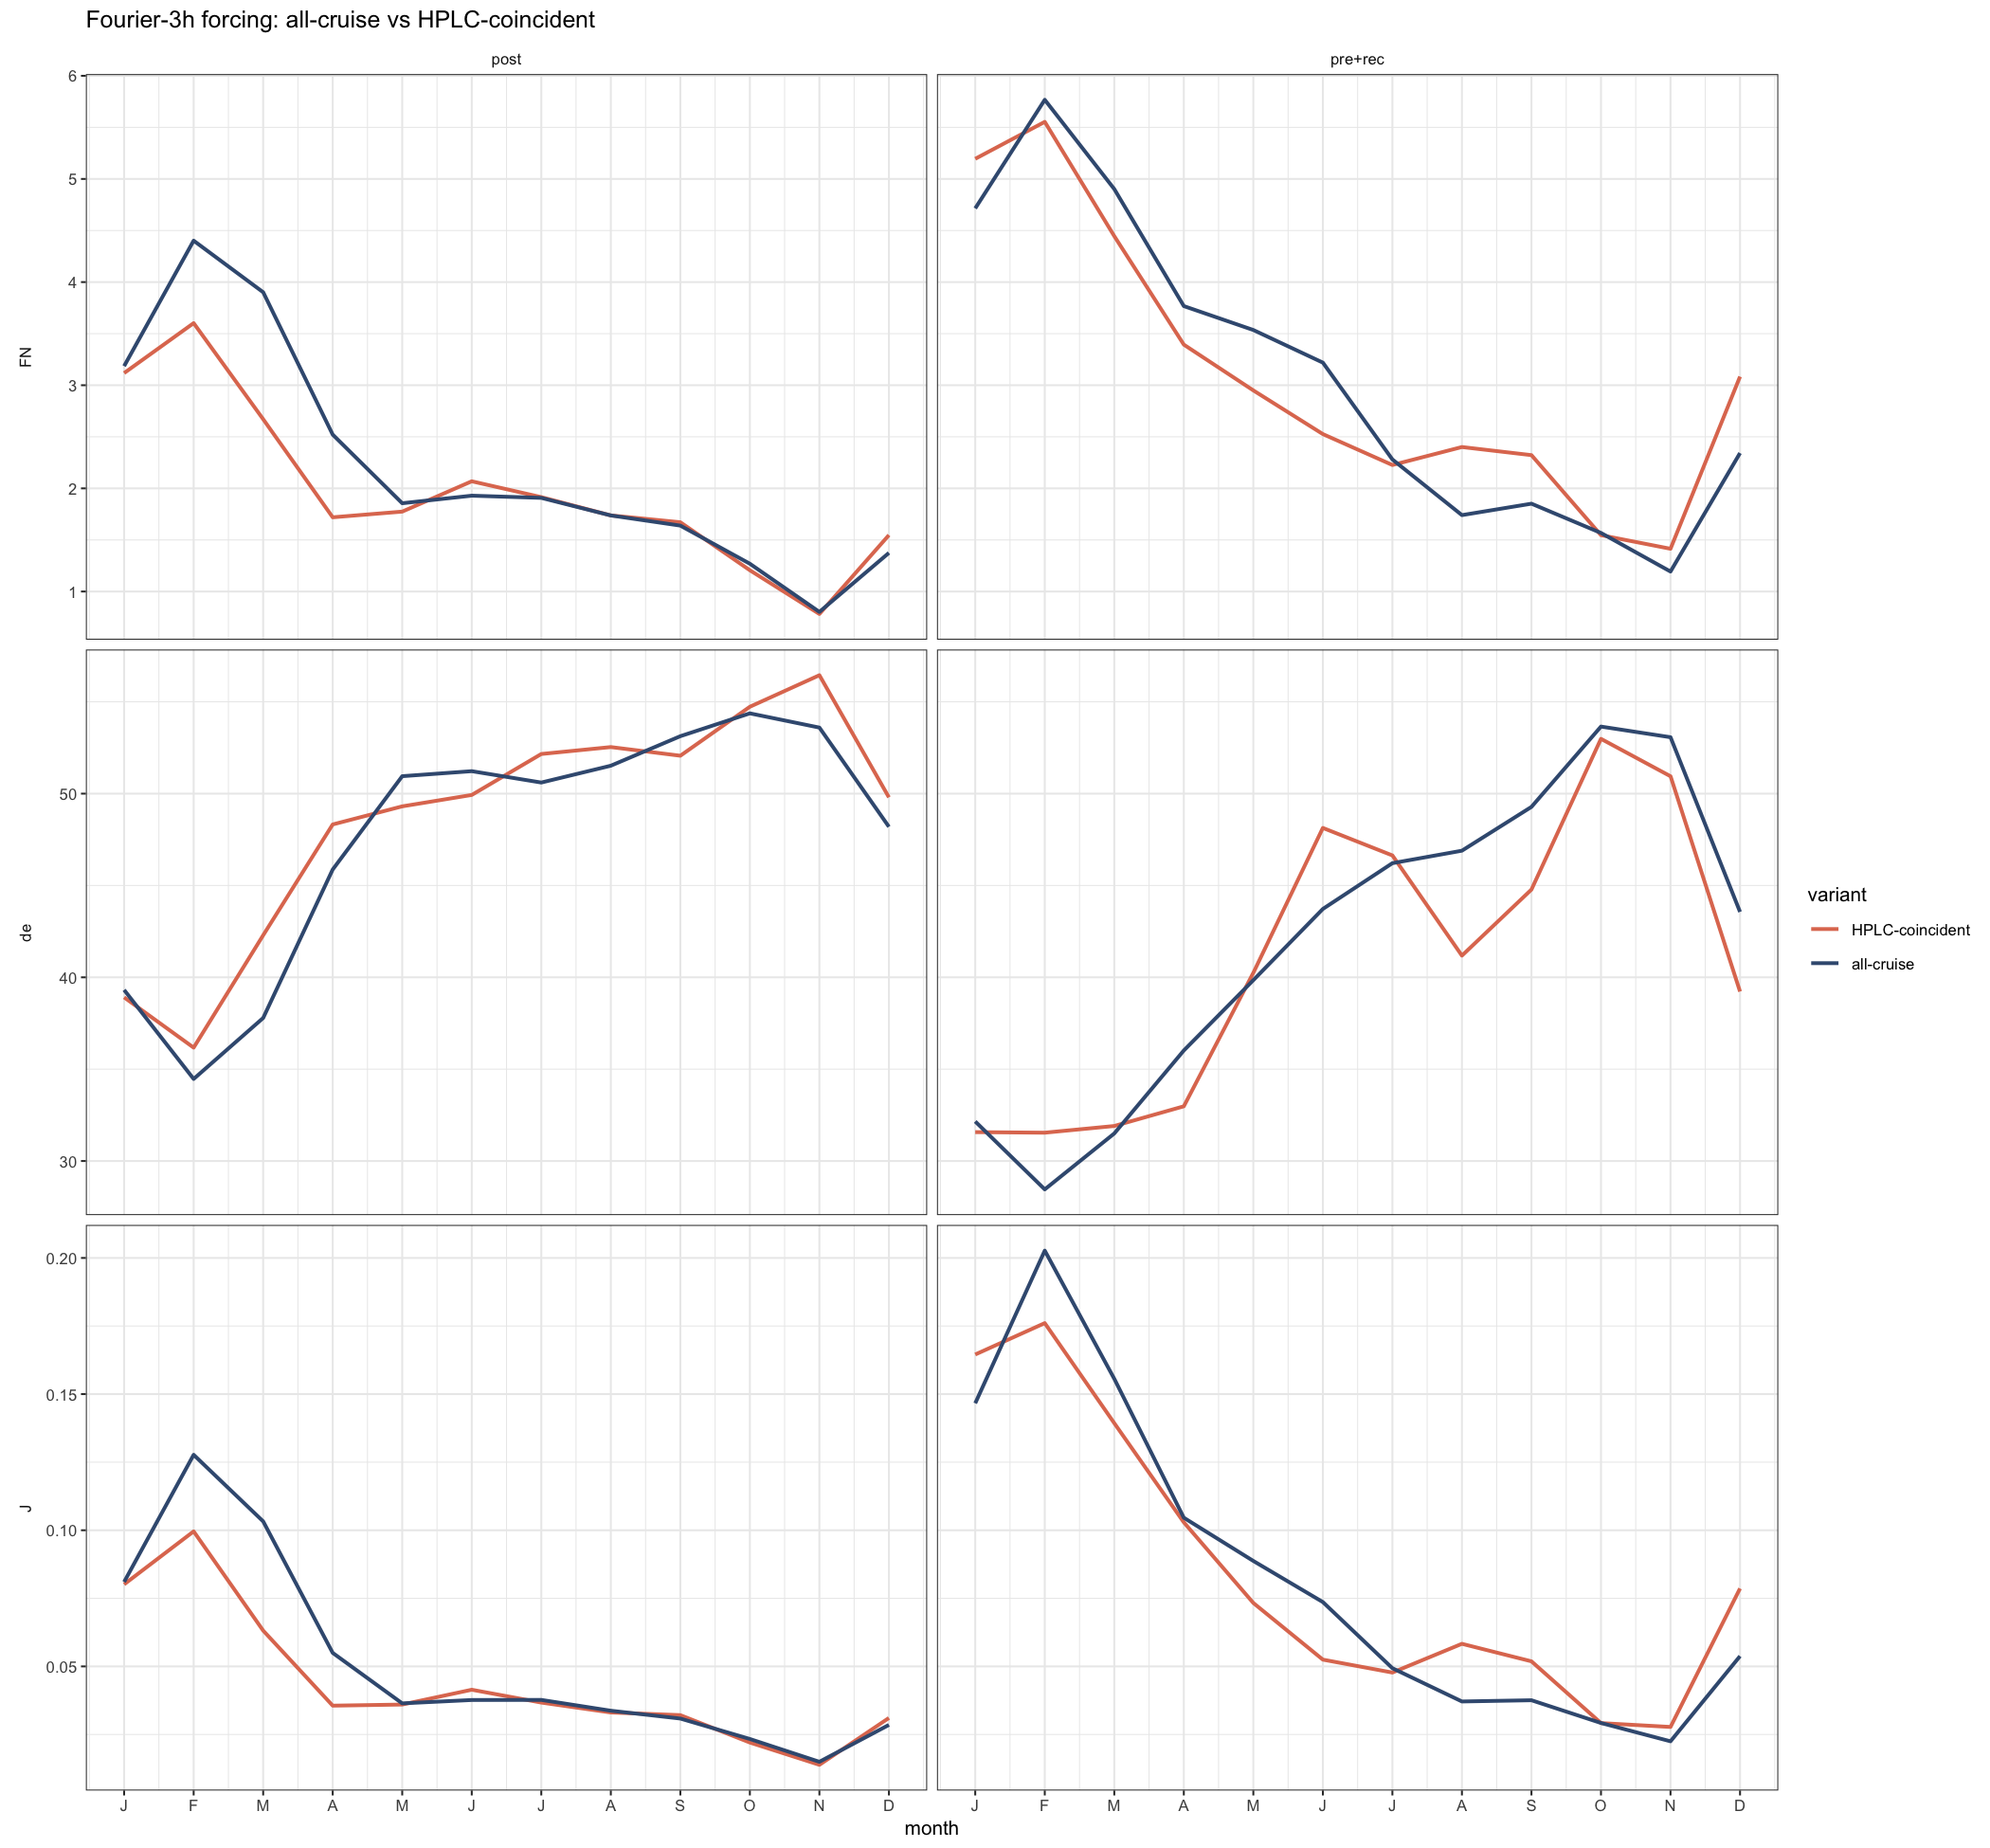

In [11]:
vrow <- function(e,hplc){ de<-D%>%filter(era==e); if(hplc) de<-de%>%filter(has_hplc)
  ffn<-fourier(clim(de,"FN_mmolN_m2_d"),3); fde<-fourier(clim(de,"depth_cutoff"),3)
  tibble(mo=1:12, FN=ffn(MIDDOY), de=fde(MIDDOY), J=ffn(MIDDOY)/fde(MIDDOY),
         era=e, variant=ifelse(hplc,"HPLC-coincident","all-cruise")) }
vlong <- map_dfr(levels(D$era),function(e) map_dfr(c(FALSE,TRUE),function(h) vrow(e,h))) %>%
  pivot_longer(c(FN,de,J),names_to="driver",values_to="val") %>% mutate(driver=factor(driver,levels=c("FN","de","J")))
print(ggplot(vlong,aes(mo,val,colour=variant))+geom_line(linewidth=0.9)+
  facet_grid(driver~era,scales="free_y",switch="y")+scale_x_continuous(breaks=1:12,labels=MOABB)+
  scale_colour_manual(values=c(`all-cruise`="#3D5A80",`HPLC-coincident`="#E07A5F"))+
  labs(x="month",y=NULL,title="Fourier-3h forcing: all-cruise vs HPLC-coincident")+
  theme_bw(base_size=10)+theme(strip.placement="outside",strip.background=element_blank()))
cat("=== fed supply J=F_N/d_e: peak month + Jan/Feb + Jan-vs-peak ratio ===\n")
vlong %>% filter(driver=="J") %>% group_by(era,variant) %>%
  summarise(peak=MOABB[which.max(val)], Jan=round(val[1],4), Feb=round(val[2],4),
            Jan_vs_peak=round(val[1]/max(val),2), .groups="drop") %>% as.data.frame() %>% print(row.names=FALSE)

=== phase: peak month, and response-minus-supply lag (negative = response leads supply) ===
  pre+rec  upwelling(iso min)=M  F_N peak=F  J peak=F  ΣP peak=M  micro peak=M | ΣP−J=+1  micro−J=+1  F_N−iso=-1 mo
  post     upwelling(iso min)=A  F_N peak=F  J peak=F  ΣP peak=J  micro peak=J | ΣP−J=-1  micro−J=-1  F_N−iso=-2 mo


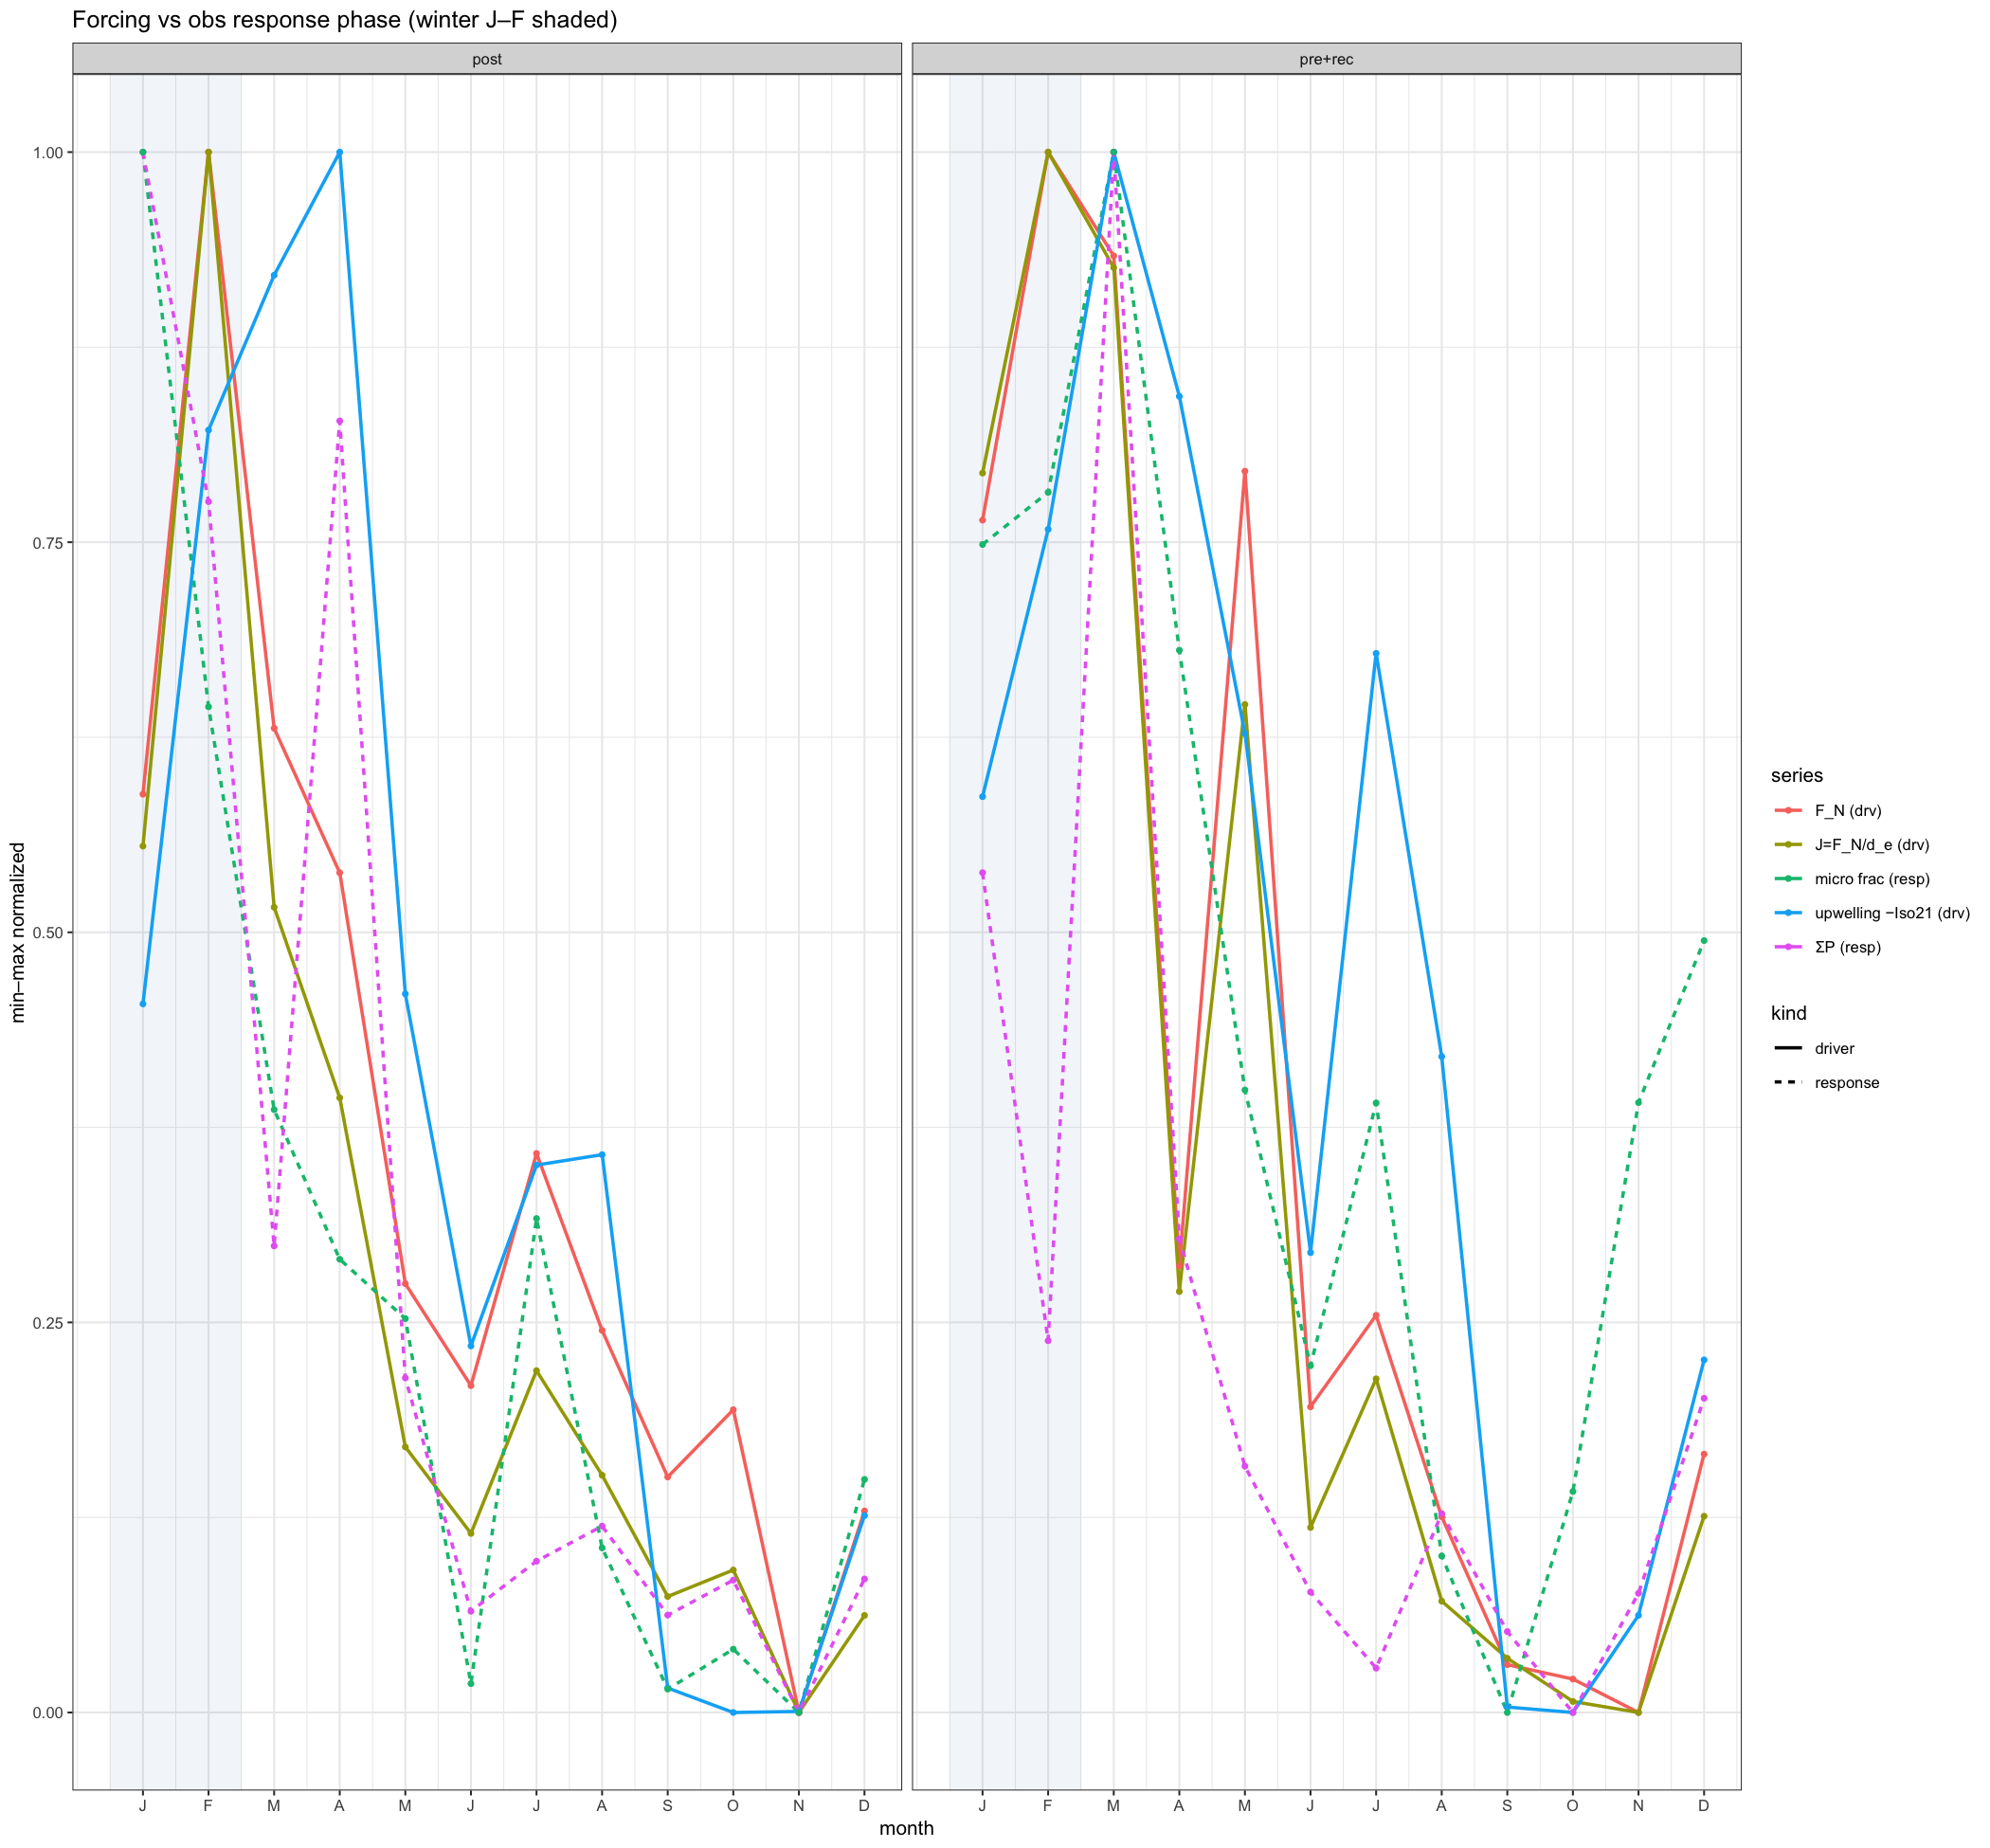

In [12]:
nrm <- function(v){ r<-range(v,na.rm=TRUE); if(diff(r)==0) v*0 else (v-r[1])/diff(r) }
series <- function(e){ de<-D%>%filter(era==e); hp<-de%>%filter(has_hplc)
  tibble(mo=1:12,
    `F_N (drv)`=nrm(clim(de,"FN_mmolN_m2_d")),
    `J=F_N/d_e (drv)`=nrm(clim(de,"FN_mmolN_m2_d")/clim(de,"depth_cutoff")),
    `upwelling −Iso21 (drv)`=nrm(-clim(de,"Isotherm_21")),
    `ΣP (resp)`=nrm(clim(hp,"sumP")),
    `micro frac (resp)`=nrm(clim(hp,"micro_frac"))) %>%
    pivot_longer(-mo,names_to="series",values_to="val") %>% mutate(era=e) }
pdat <- map_dfr(levels(D$era),series) %>% mutate(kind=ifelse(grepl("resp",series),"response","driver"))
print(ggplot(pdat,aes(mo,val,colour=series,linetype=kind))+
  annotate("rect",xmin=0.5,xmax=2.5,ymin=-Inf,ymax=Inf,fill="steelblue",alpha=0.07)+
  geom_line(linewidth=0.8)+geom_point(size=1)+facet_wrap(~era)+
  scale_x_continuous(breaks=1:12,labels=MOABB)+scale_linetype_manual(values=c(driver="solid",response="22"))+
  labs(x="month",y="min–max normalized",title="Forcing vs obs response phase (winter J–F shaded)")+
  theme_bw(base_size=10)+theme(legend.position="right"))

cat("=== phase: peak month, and response-minus-supply lag (negative = response leads supply) ===\n")
for(e in levels(D$era)){ de<-D%>%filter(era==e); hp<-de%>%filter(has_hplc)
  Jp<-which.max(clim(de,"FN_mmolN_m2_d")/clim(de,"depth_cutoff")); FNp<-which.max(clim(de,"FN_mmolN_m2_d"))
  isop<-which.min(clim(de,"Isotherm_21")); SPp<-which.max(clim(hp,"sumP")); MFp<-which.max(clim(hp,"micro_frac"))
  cat(sprintf("  %-8s upwelling(iso min)=%s  F_N peak=%s  J peak=%s  ΣP peak=%s  micro peak=%s | ΣP−J=%+d  micro−J=%+d  F_N−iso=%+d mo\n",
      e, MOABB[isop], MOABB[FNp], MOABB[Jp], MOABB[SPp], MOABB[MFp], SPp-Jp, MFp-Jp, FNp-isop)) }

In [13]:
MN <- month.name
pk <- function(v,k="max") if(k=="min") which.min(v) else which.max(v)
blag <- function(x,y){ Ls<- -4:4; r<-sapply(Ls,function(L) cor(x,y[((seq_along(y)-1-L)%%12)+1]))
                       c(lag=Ls[which.max(r)], r=round(max(r),2)) }
report <- function(hplc_only){
  for(e in levels(D$era)){
    fd<-D%>%filter(era==e); if(hplc_only) fd<-fd%>%filter(has_hplc)
    fn<-clim(fd,"FN_mmolN_m2_d"); dee<-clim(fd,"depth_cutoff"); iso<-clim(fd,"Isotherm_21"); J<-fn/dee
    hp<-D%>%filter(era==e,has_hplc); SP<-clim(hp,"sumP"); MF<-clim(hp,"micro_frac")
    cat(sprintf("\n--- %-8s [%s; forcing n=%d cruises] ---\n", e,
        if(hplc_only)"HPLC-coincident" else "all-cruise", sum(is.finite(fd$FN_mmolN_m2_d))))
    cat(sprintf("  PEAK  F_N=%-9s J=%-9s | iso-shallow=%-9s d_e-shallow=%-9s | ΣP=%-9s micro=%-9s\n",
        MN[pk(fn)],MN[pk(J)],MN[pk(iso,"min")],MN[pk(dee,"min")],MN[pk(SP)],MN[pk(MF)]))
    cat(sprintf("  peak diff (response - J):  ΣP %+d mo   micro %+d mo   (negative = response LEADS supply)\n",
        pk(SP)-pk(J), pk(MF)-pk(J)))
    a<-blag(J,SP); b<-blag(J,MF)
    cat(sprintf("  cross-corr best lag vs J:  ΣP %+d mo (r=%.2f)   micro %+d mo (r=%.2f)\n",a["lag"],a["r"],b["lag"],b["r"]))
  }
}
cat("======== ALL-CRUISE forcing ========"); report(FALSE)
cat("\n\n======== HPLC-COINCIDENT (matched cruises) ========"); report(TRUE)

======== ALL-CRUISE forcing ========
--- pre+rec  [all-cruise; forcing n=105 cruises] ---
  PEAK  F_N=February  J=February  | iso-shallow=March     d_e-shallow=January   | ΣP=March     micro=March    
  peak diff (response - J):  ΣP +1 mo   micro +1 mo   (negative = response LEADS supply)
  cross-corr best lag vs J:  ΣP +0 mo (r=0.71)   micro +0 mo (r=0.82)

--- post     [all-cruise; forcing n=80 cruises] ---
  PEAK  F_N=February  J=February  | iso-shallow=April     d_e-shallow=February  | ΣP=January   micro=January  
  peak diff (response - J):  ΣP -1 mo   micro -1 mo   (negative = response LEADS supply)
  cross-corr best lag vs J:  ΣP +0 mo (r=0.80)   micro +1 mo (r=0.85)


======== HPLC-COINCIDENT (matched cruises) ========
--- pre+rec  [HPLC-coincident; forcing n=37 cruises] ---
  PEAK  F_N=January   J=January   | iso-shallow=April     d_e-shallow=January   | ΣP=March     micro=March    
  peak diff (response - J):  ΣP +2 mo   micro +2 mo   (negative = response LEADS supply)
  cros

In [14]:
wms <- function(e){ de<-D%>%filter(era==e); hp<-de%>%filter(has_hplc)
  tibble(mo=month.abb, era=e,
    F_N=round(clim(de,"FN_mmolN_m2_d"),2),
    J  =round(clim(de,"FN_mmolN_m2_d")/clim(de,"depth_cutoff"),3),
    sumP_mean=round(clim(hp,"sumP"),2),   sumP_med=round(clim(hp,"sumP","median"),2),
    micro_mean=round(clim(hp,"micro_frac"),2), micro_med=round(clim(hp,"micro_frac","median"),2)) }
W <- map_dfr(levels(D$era), wms)
cat("=== winter window (monthly climatology) ===\n")
W %>% filter(mo %in% c("Nov","Dec","Jan","Feb","Mar","Apr")) %>%
  arrange(era, match(mo,month.abb)) %>% as.data.frame() %>% print(row.names=FALSE)

neigh <- function(v){ p<-which.max(v); v[p]/mean(c(v[((p-2)%%12)+1], v[(p%%12)+1])) }  # peak / mean(both neighbours)
cat("\n=== peak stick-out ratio (peak / mean of adjacent months; ~1 = plateau, >~1.3 = spike) ===\n")
for(e in levels(D$era)){ de<-D%>%filter(era==e); hp<-de%>%filter(has_hplc)
  fn<-clim(de,"FN_mmolN_m2_d"); J<-fn/clim(de,"depth_cutoff"); SP<-clim(hp,"sumP"); MF<-clim(hp,"micro_frac")
  cat(sprintf("  %-8s  F_N %.2f  J %.2f  sumP %.2f  micro %.2f\n", e, neigh(fn),neigh(J),neigh(SP),neigh(MF))) }

cat("\n=== January as fraction of each series' annual peak (is Jan supply already high?) ===\n")
for(e in levels(D$era)){ de<-D%>%filter(era==e); hp<-de%>%filter(has_hplc)
  fn<-clim(de,"FN_mmolN_m2_d"); J<-fn/clim(de,"depth_cutoff"); SP<-clim(hp,"sumP"); MF<-clim(hp,"micro_frac")
  cat(sprintf("  %-8s  F_N %.2f  J %.2f  sumP %.2f  micro %.2f\n", e, fn[1]/max(fn),J[1]/max(J),SP[1]/max(SP),MF[1]/max(MF))) }

=== winter window (monthly climatology) ===
  mo     era  F_N     J sumP_mean sumP_med micro_mean micro_med
 Jan    post 3.14 0.087      1.26     1.43       0.82      0.86
 Feb    post 4.80 0.143      1.06     1.05       0.58      0.56
 Mar    post 3.31 0.082      0.63     0.55       0.41      0.42
 Apr    post 2.93 0.066      1.11     0.55       0.35      0.28
 Nov    post 0.75 0.016      0.36     0.33       0.15      0.15
 Dec    post 1.28 0.024      0.43     0.43       0.25      0.16
 Jan pre+rec 4.71 0.156      1.43     1.36       0.71      0.73
 Feb pre+rec 5.71 0.190      0.81     0.63       0.73      0.73
 Mar pre+rec 5.43 0.178      2.39     2.39       0.89      0.89
 Apr pre+rec 2.67 0.071      0.95     0.98       0.66      0.75
 Nov pre+rec 1.45 0.027      0.48     0.52       0.45      0.46
 Dec pre+rec 2.16 0.048      0.74     0.55       0.53      0.61

=== peak stick-out ratio (peak / mean of adjacent months; ~1 = plateau, >~1.3 = spike) ===
  pre+rec   F_N 1.13  J 1.14  su

In [20]:
library(tidyverse)
csv <- read.csv("../processed/cariaco_monthly_euphotic_dynamic.csv") %>%
  mutate(date=as.Date(date), ym=format(date,"%Y-%m"),
         sumP=micro_mmolN+nano_mmolN+pico_mmolN) %>% arrange(date)
peaks <- as.Date(c("2009-01-01","2011-01-01","2012-01-01","2011-02-01","2008-01-01"))
win <- 3
for(i in seq_along(peaks)){ p <- peaks[i]; idx <- which(csv$date==p)
  cat(sprintf("\n========  peak cruise %s  ========\n", format(p,"%Y-%m")))
  csv[max(1,idx-win):min(nrow(csv),idx+win),] %>%
    transmute(ym, F_N=round(FN_mmolN_m2_d,2), J=round(FN_mmolN_m2_d/depth_cutoff,3),
              sumP=round(sumP,2), micro=round(micro_frac,2),
              d_e=round(depth_cutoff,1), cutoff_source, hplc=!is.na(micro_frac)) %>%
    as.data.frame() %>% print(row.names=FALSE) }


========  peak cruise 2009-01  ========
      ym  F_N     J sumP micro  d_e      cutoff_source  hplc
 2008-10   NA    NA 0.31  0.13 55.5 isotherm_chl_model  TRUE
 2008-11   NA    NA   NA    NA   NA      no_prediction FALSE
 2008-12 0.39 0.007 0.41  0.09 54.2 isotherm_chl_model  TRUE
 2009-01 4.04 0.137 1.07  0.81 29.5 isotherm_chl_model  TRUE
 2009-02   NA    NA 0.61  0.56 47.0 isotherm_chl_model  TRUE
 2009-03 2.01 0.052 0.69  0.50 38.3 isotherm_chl_model  TRUE
 2009-04   NA    NA 0.47  0.25 46.8 isotherm_chl_model  TRUE

========  peak cruise 2011-01  ========
      ym  F_N     J sumP micro  d_e      cutoff_source  hplc
 2010-10 0.61 0.012 0.34  0.17 52.8 isotherm_chl_model  TRUE
 2010-11 0.50 0.010 0.40  0.18 50.9           observed  TRUE
 2010-12 1.46 0.029 0.52  0.37 49.6 isotherm_chl_model  TRUE
 2011-01   NA    NA 1.79  0.91 31.6 isotherm_chl_model  TRUE
 2011-02 3.69 0.150 1.52  0.94 24.5 isotherm_chl_model  TRUE
 2011-03 1.93 0.040 0.39  0.25 47.9 isotherm_chl_model  TRUE
 20

Warning message:
“Removed 143 rows containing missing values or values outside the scale range
(`geom_path()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_hline()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_path()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_hline()`).”


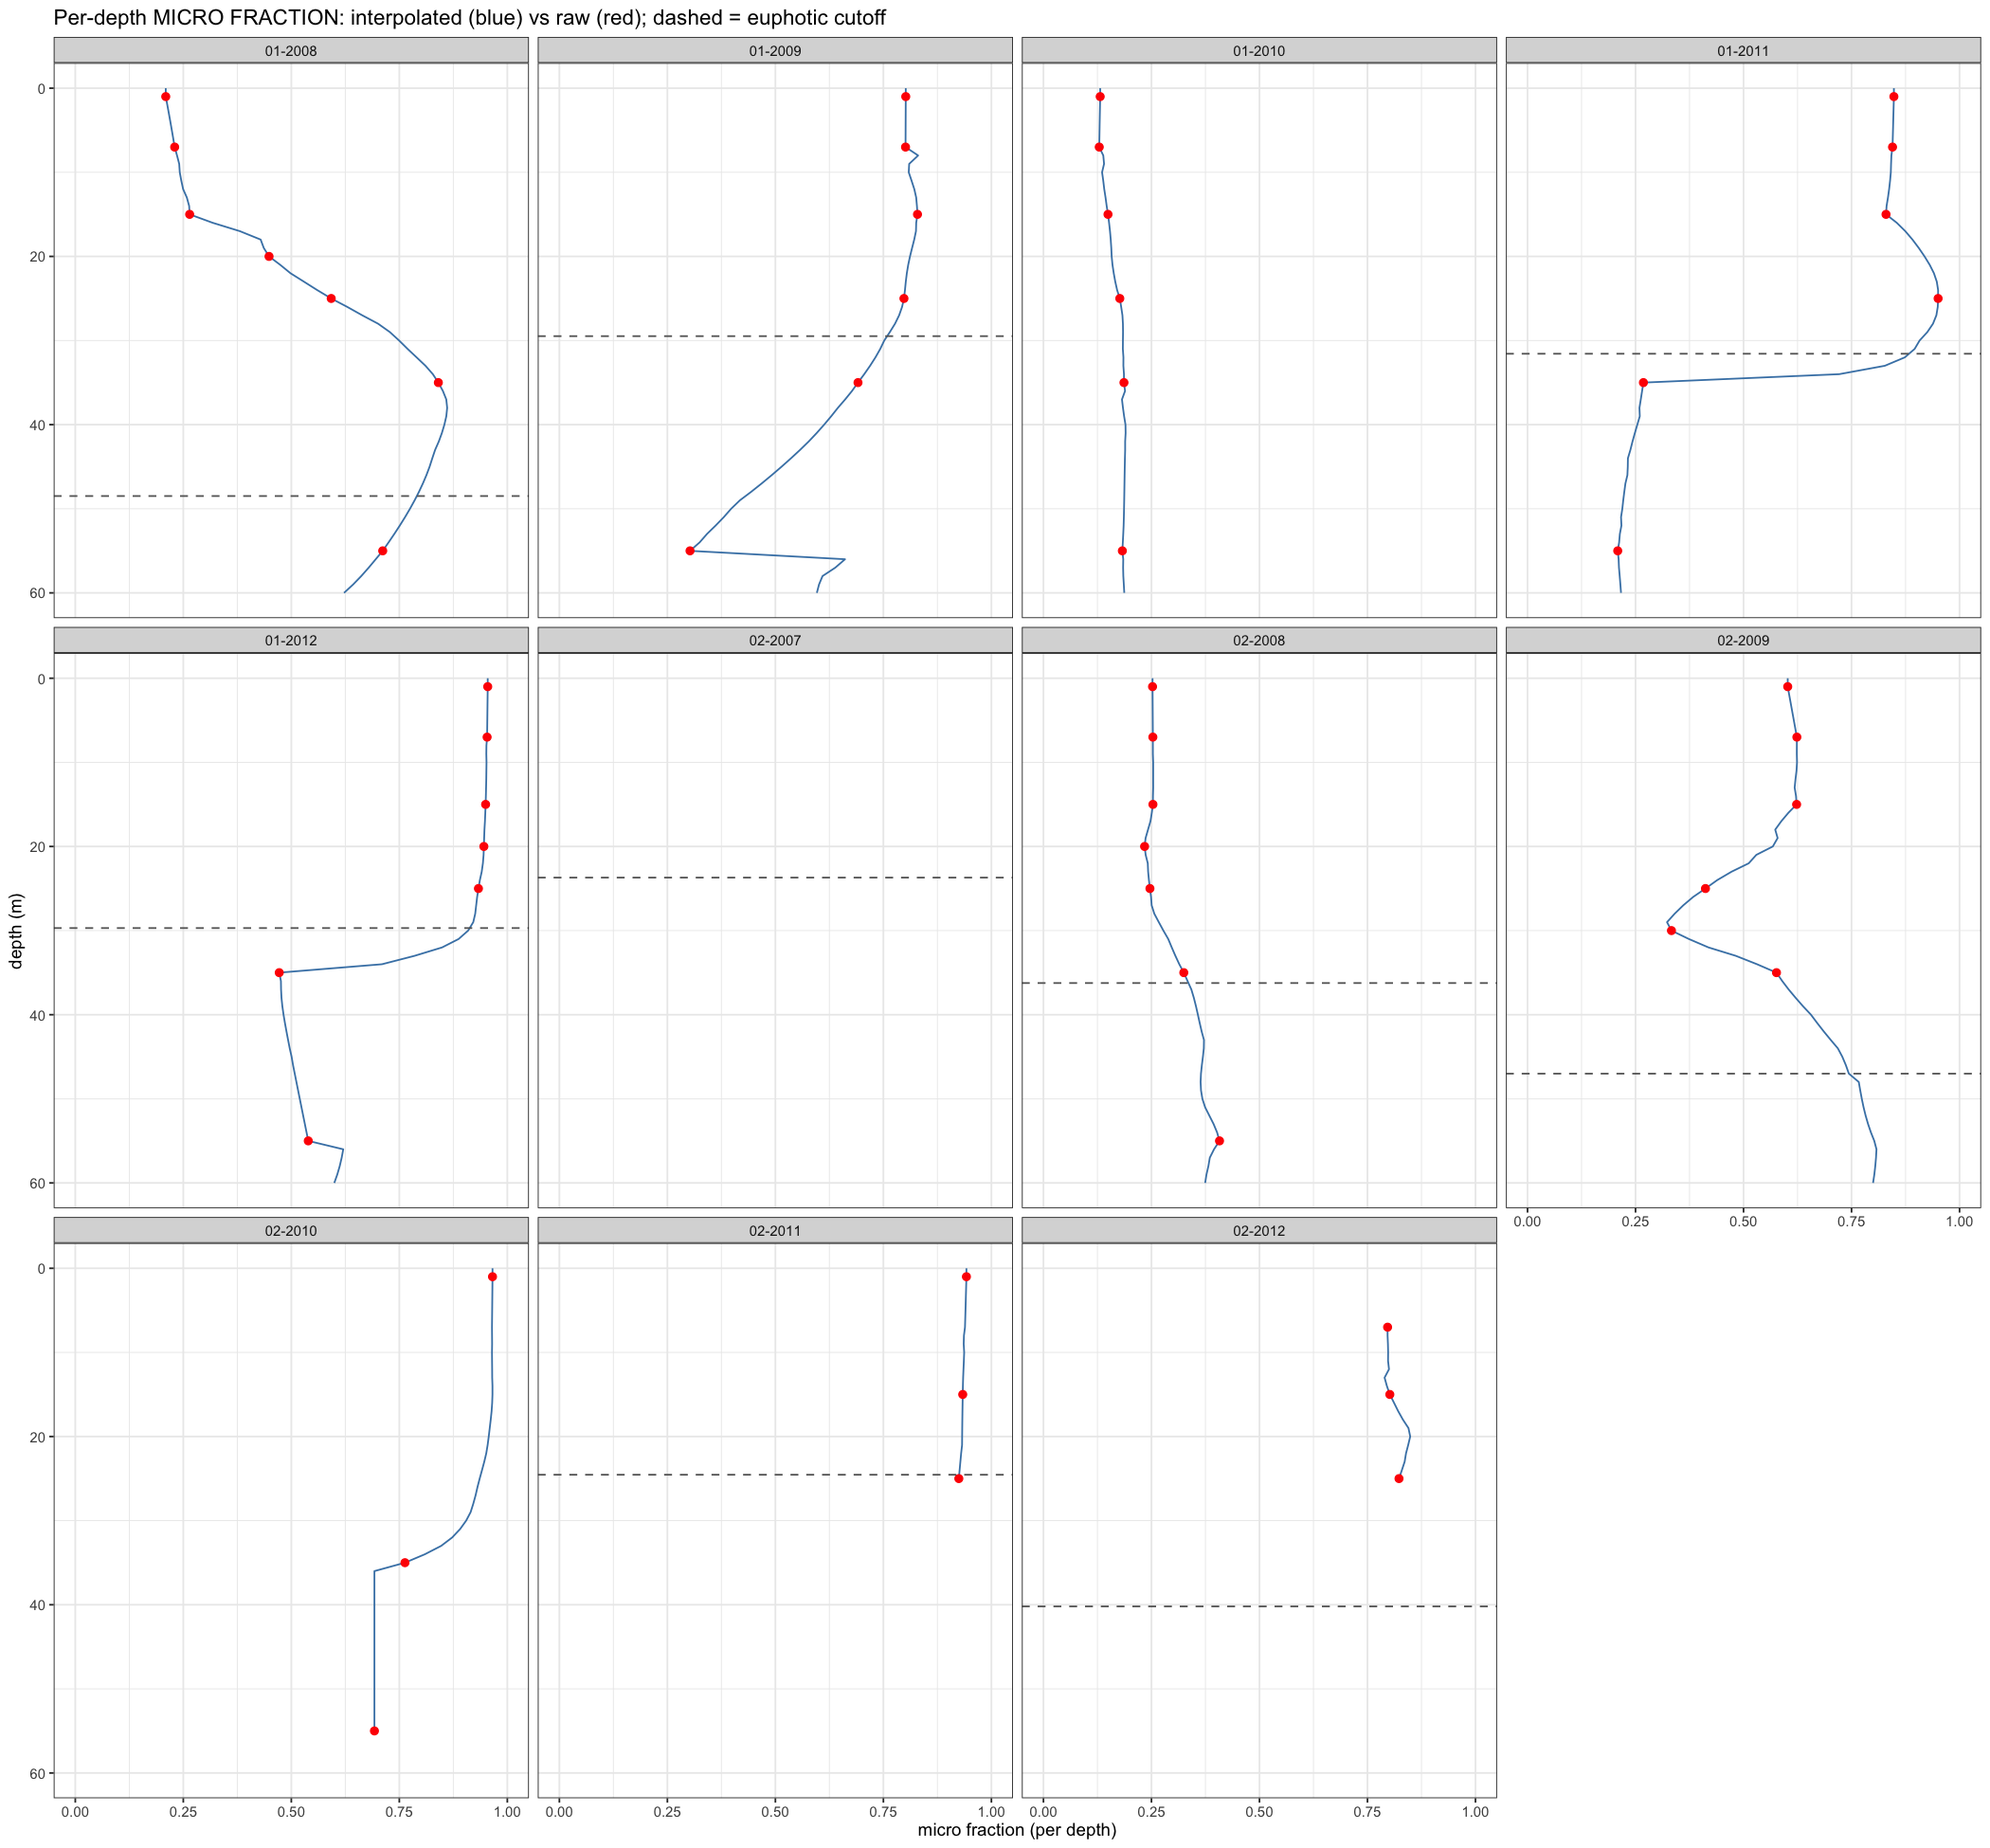

=== per-cruise support (fixed) ===


Warning message:
“There were 5 warnings in `summarise()`.
The first warning was:
ℹ In argument: `shallowest = min(depth[!is.na(micro_d)])`.
ℹ In group 6: `time_month = "02-2007"`.
Caused by warning in `min()`:
! kein nicht-fehlendes Argument für min; gebe Inf zurück
ℹ Run `dplyr::last_dplyr_warnings()` to see the 4 remaining warnings.”


 time_month depth_cutoff n_micro n_in_euz shallowest deepest extrap_below
    01-2008     48.48711       9        6          1     100        FALSE
    01-2009     29.47845       7        4          1      75        FALSE
    01-2010           NA       7       NA          1      75           NA
    01-2011     31.57041       7        4          1      75        FALSE
    01-2012     29.70000       8        5          1      75        FALSE
    02-2007     23.70000       0        0        Inf    -Inf         TRUE
    02-2008     36.23659       9        6          1     100        FALSE
    02-2009     47.00591       8        6          1     100        FALSE
    02-2010           NA       3       NA          1      55           NA
    02-2011     24.54329       3        2          1      25        FALSE
    02-2012     40.20000       3        3          7      25         TRUE
 micro_surf micro_range
       0.21   0.21–0.84
       0.80   0.30–0.83
       0.13   0.13–0.24
       0.85   0.

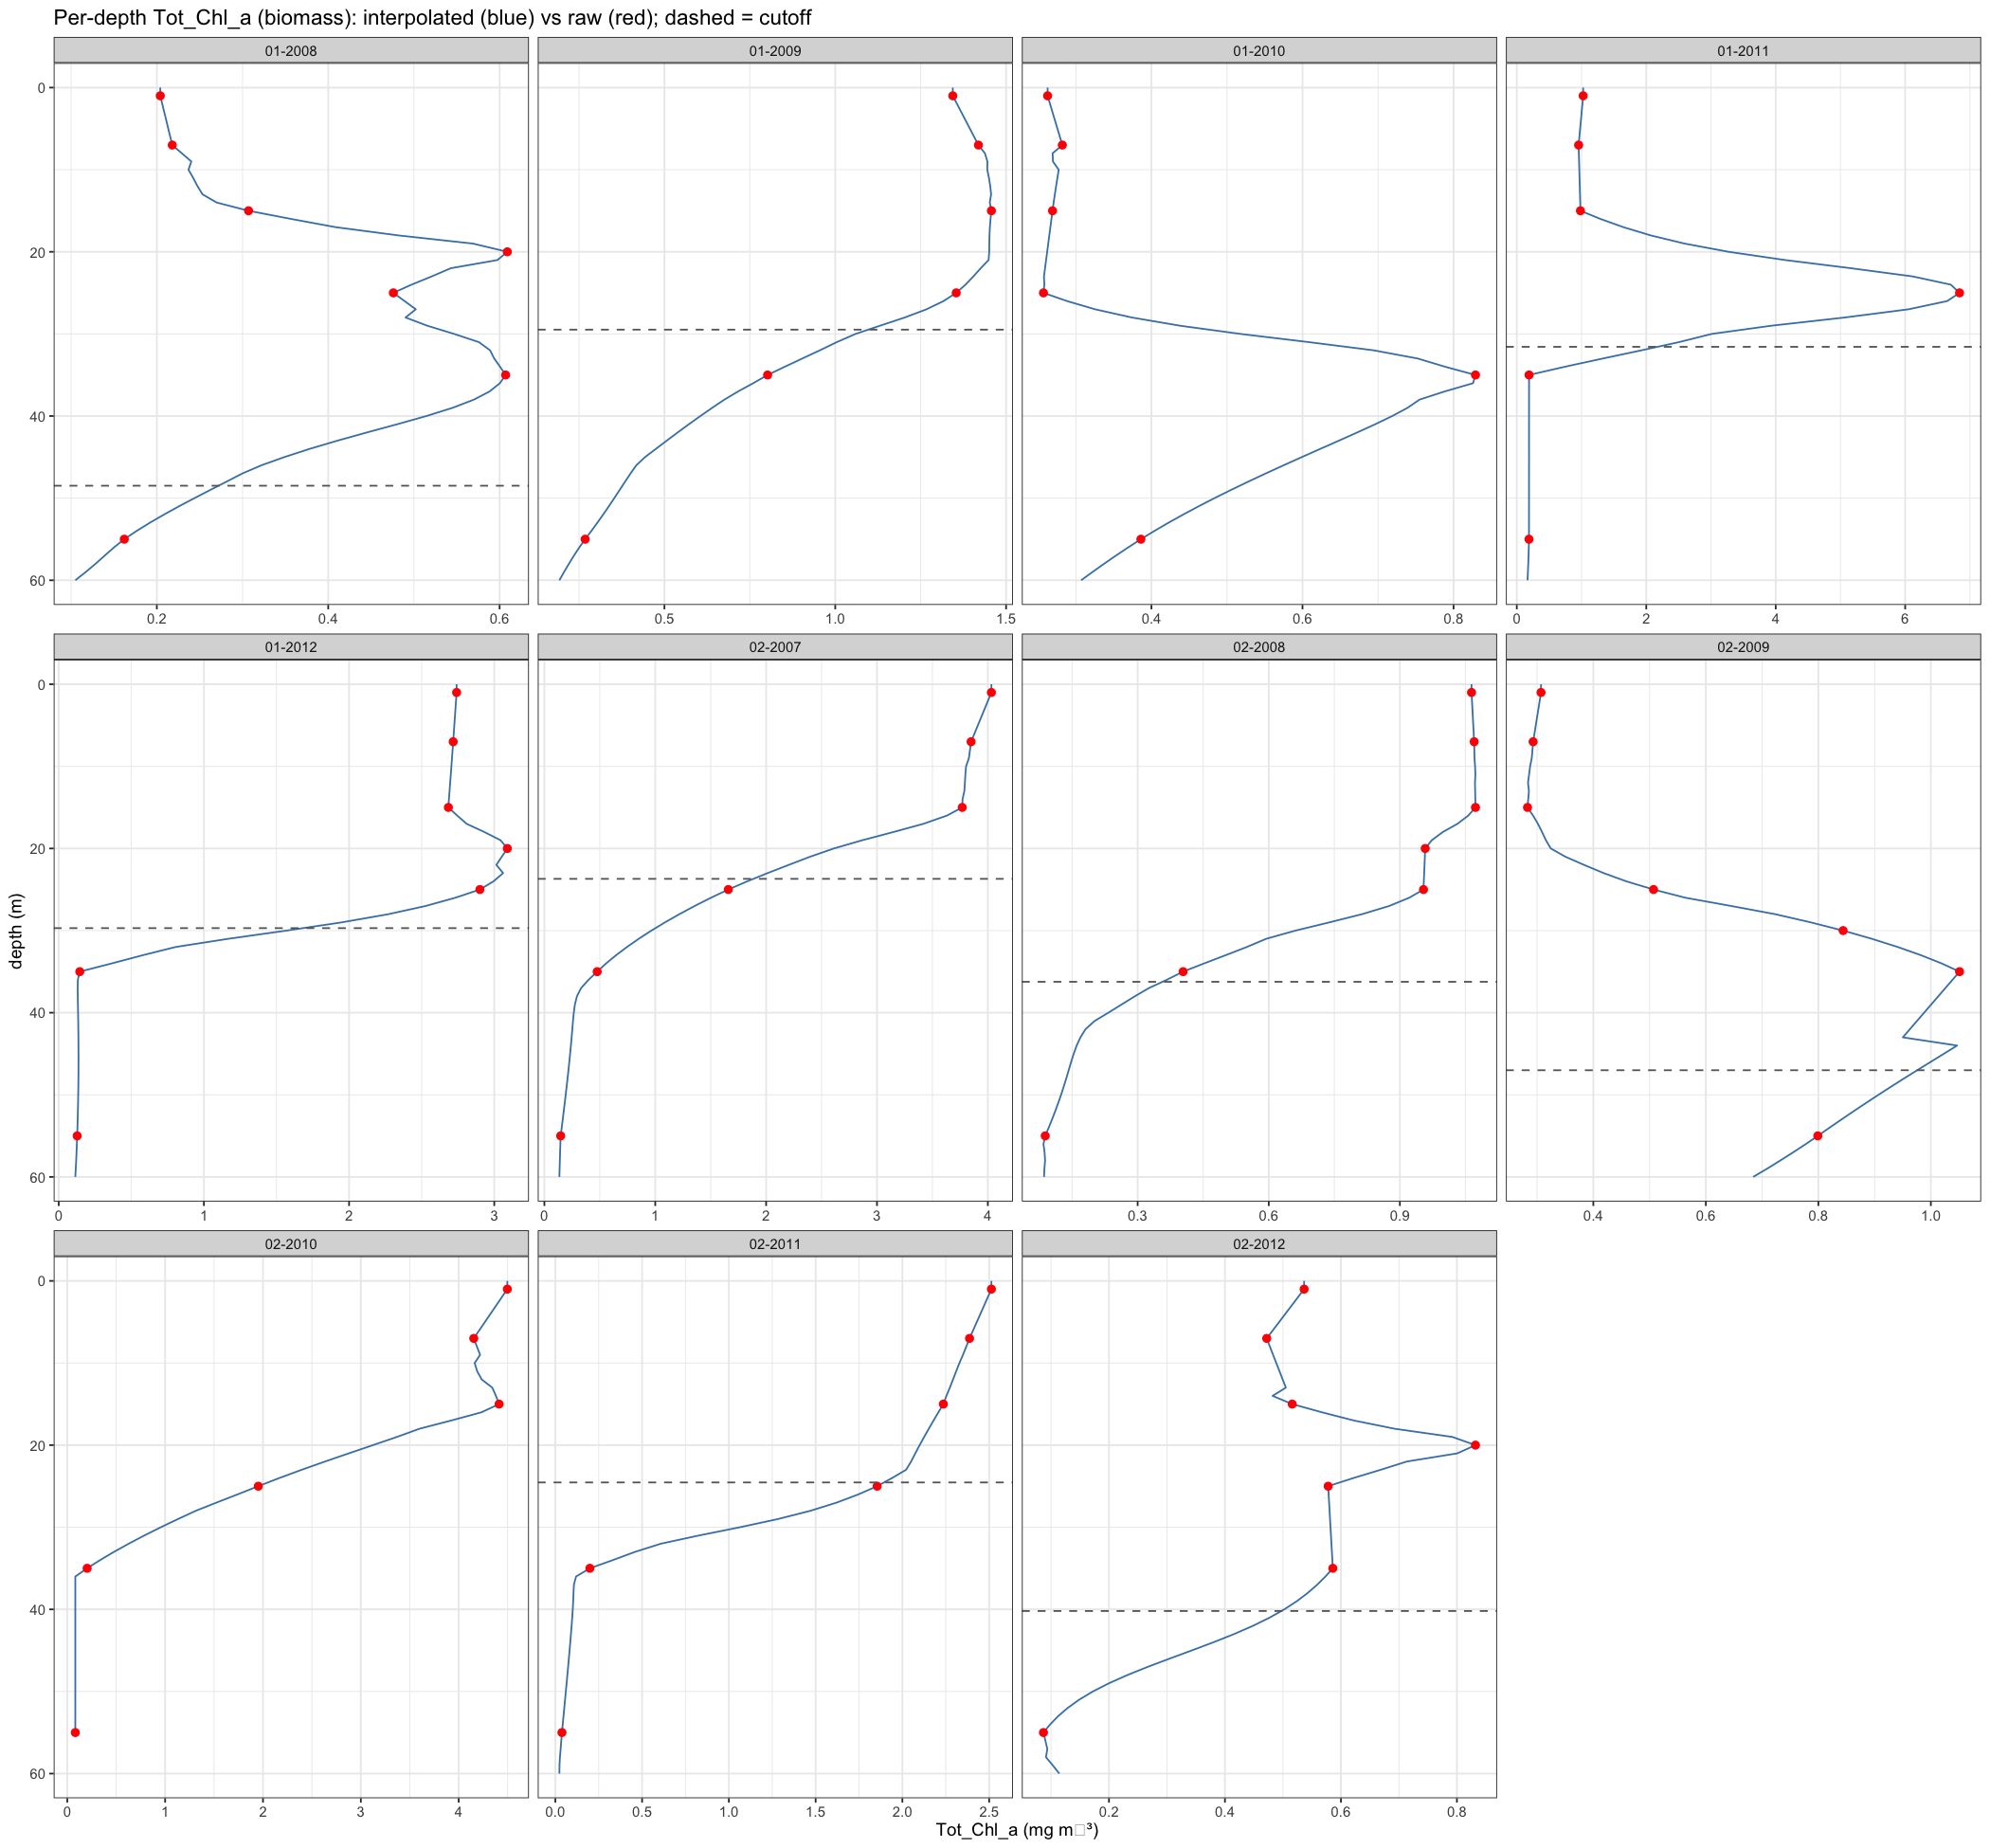

In [21]:
# interpolate all DP pigments + Tot_Chl_a on the 1 m grid, build the per-depth micro fraction
ivar <- function(v) interpolateDF(prepdataframe(Mesh_HPLC %>% filter(date %in% post_jf), v)) %>%
  transmute(date, depth, !!v := value_int)
dp <- c("Fuco","Perid","Allo","But_fuco","Hex_fuco","Zea","Tot_Chl_b")
ipw <- reduce(lapply(c(dp,"Tot_Chl_a"), ivar), full_join, by=c("date","depth")) %>%
  mutate(DP2=1.41*Fuco+1.41*Perid+0.60*Allo+0.35*But_fuco+1.27*Hex_fuco+0.86*Zea+1.01*Tot_Chl_b,
         micro_d=ifelse(DP2>0.001,(1.41*Fuco+1.41*Perid)/DP2,NA), time_month=format(date,"%m-%Y"))

print(ggplot() +
  geom_path(data=ipw%>%filter(depth<=60), aes(micro_d,depth,group=date), colour="steelblue") +
  geom_point(data=raw%>%filter(depth<=60,!is.na(micro_d)), aes(micro_d,depth), colour="red", size=1.6) +
  geom_hline(data=raw%>%distinct(time_month,depth_cutoff), aes(yintercept=depth_cutoff), linetype="dashed", colour="grey40") +
  scale_y_reverse() + facet_wrap(~time_month) + xlim(0,1) +
  labs(x="micro fraction (per depth)", y="depth (m)",
       title="Per-depth MICRO FRACTION: interpolated (blue) vs raw (red); dashed = euphotic cutoff") +
  theme_bw(base_size=9))

print(ggplot() +
  geom_path(data=ipw%>%filter(depth<=60), aes(Tot_Chl_a,depth,group=date), colour="steelblue") +
  geom_point(data=raw%>%filter(depth<=60,!is.na(Tot_Chl_a)), aes(Tot_Chl_a,depth), colour="red", size=1.6) +
  geom_hline(data=raw%>%distinct(time_month,depth_cutoff), aes(yintercept=depth_cutoff), linetype="dashed", colour="grey40") +
  scale_y_reverse() + facet_wrap(~time_month, scales="free_x") +
  labs(x="Tot_Chl_a (mg m⁻³)", y="depth (m)",
       title="Per-depth Tot_Chl_a (biomass): interpolated (blue) vs raw (red); dashed = cutoff") +
  theme_bw(base_size=9))

cat("=== per-cruise support (fixed) ===\n")
raw %>% group_by(time_month) %>%
  summarise(depth_cutoff=first(depth_cutoff),
            n_micro=sum(!is.na(micro_d)), n_in_euz=sum(!is.na(micro_d) & depth<=first(depth_cutoff)),
            shallowest=min(depth[!is.na(micro_d)]), deepest=max(depth[!is.na(micro_d)]),
            extrap_below = max(depth[!is.na(micro_d)]) < first(depth_cutoff),
            micro_surf=round(micro_d[which.min(depth)],2),
            micro_range=sprintf("%.2f–%.2f", min(micro_d,na.rm=TRUE), max(micro_d,na.rm=TRUE)),
            .groups="drop") %>% as.data.frame() %>% print(row.names=FALSE)

Warning message:
“Removed 35 rows containing missing values or values outside the scale range
(`geom_path()`).”


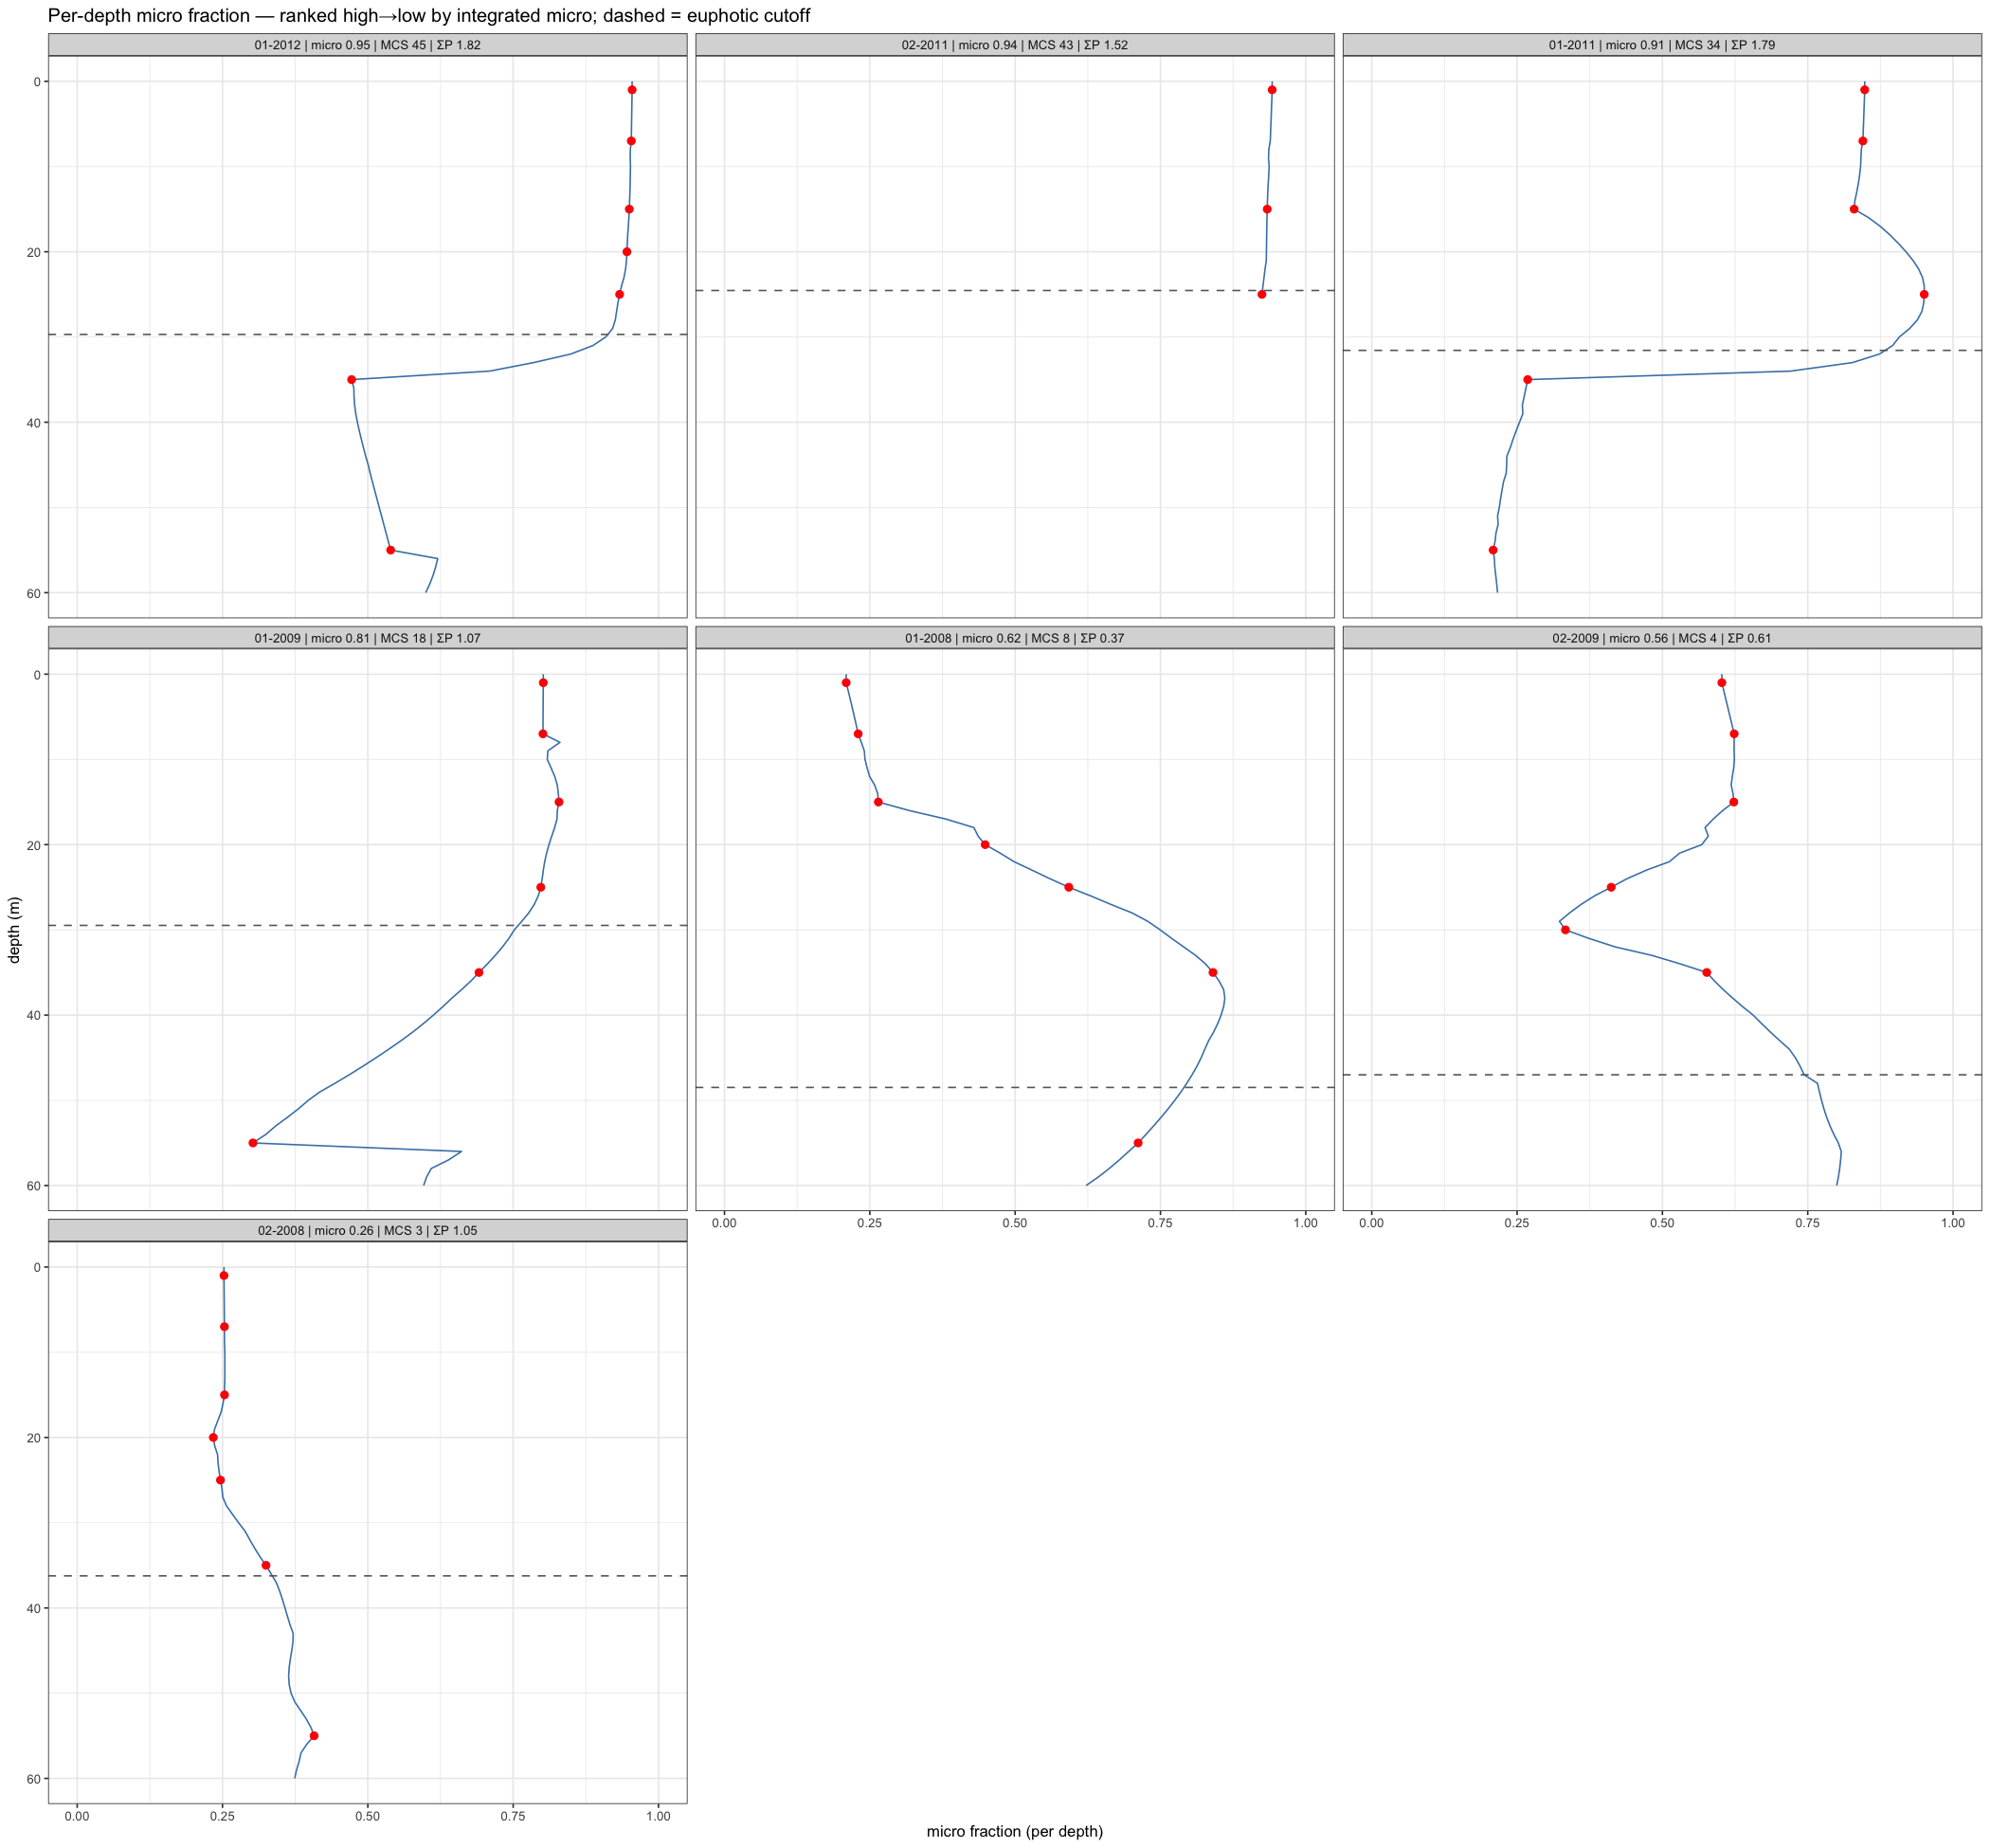

=== per-cruise support, ranked by integrated micro (in-product only) ===
 time_month micro_frac  mcs depth_cutoff n_micro n_in_euz shallowest deepest
    01-2012  0.9466762 44.7         29.7       8        5          1      75
    02-2011  0.9358829 42.7         24.5       3        2          1      25
    01-2011  0.9098177 33.9         31.6       7        4          1      75
    01-2009  0.8075372 18.1         29.5       7        4          1      75
    01-2008  0.6161662  7.8         48.5       9        6          1     100
    02-2009  0.5569550  4.1         47.0       8        6          1     100
    02-2008  0.2567591  2.8         36.2       9        6          1     100
 extrap_below micro_surf micro_range
        FALSE       0.95   0.47–0.95
        FALSE       0.94   0.92–0.94
        FALSE       0.85   0.21–0.95
        FALSE       0.80   0.30–0.83
        FALSE       0.21   0.21–0.84
        FALSE       0.60   0.33–0.63
        FALSE       0.25   0.23–0.58


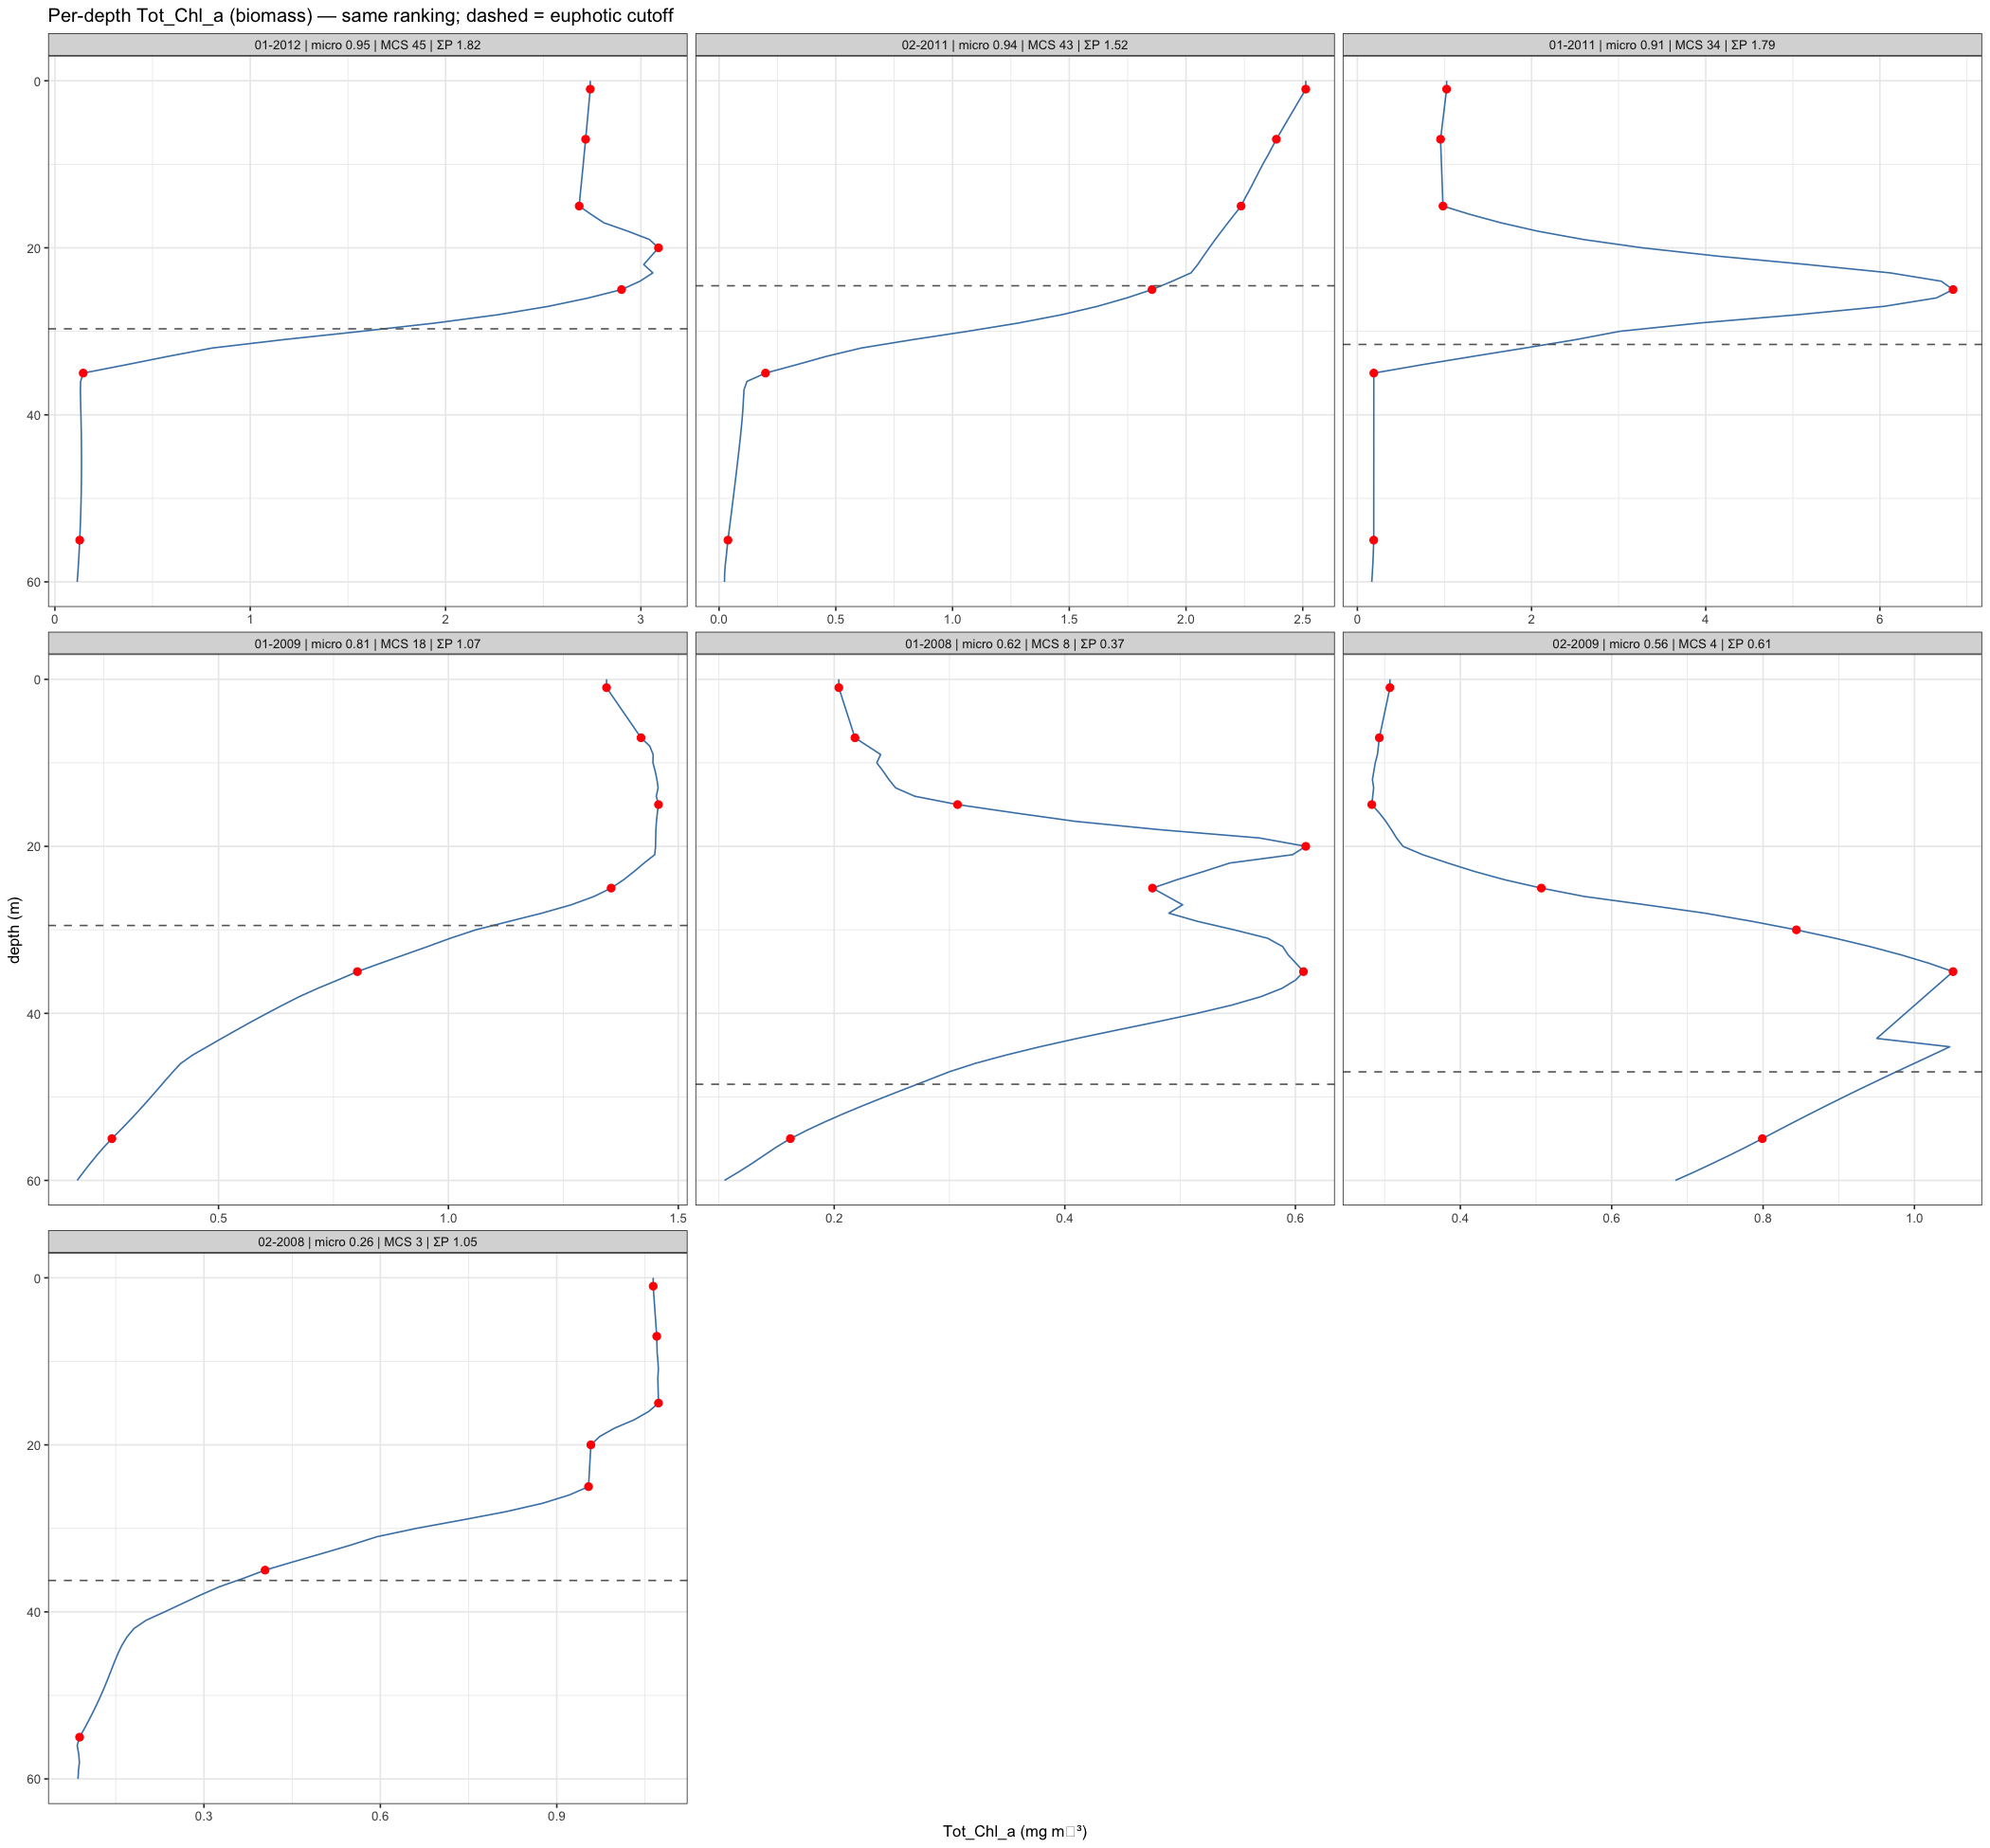

In [22]:
library(tidyverse)
# 1. ranking + labels from the PRODUCT (in-comparison cruises only)
prod <- read.csv("../processed/cariaco_monthly_euphotic_dynamic.csv") %>%
  mutate(date=as.Date(date), time_month=format(date,"%m-%Y"),
         yr=as.integer(format(date,"%Y")), mo=as.integer(format(date,"%m")),
         sumP=micro_mmolN+nano_mmolN+pico_mmolN, mcs=10^size_centroid) %>%
  filter(yr>=2005, yr<2014, mo %in% 1:2, !is.na(depth_cutoff), !is.na(micro_frac)) %>%
  transmute(time_month, depth_cutoff, micro_frac, mcs, sumP) %>% arrange(desc(micro_frac)) %>%
  mutate(lab=factor(sprintf("%s | micro %.2f | MCS %.0f | ΣP %.2f", time_month, micro_frac, mcs, sumP),
                    levels=sprintf("%s | micro %.2f | MCS %.0f | ΣP %.2f", time_month, micro_frac, mcs, sumP)))
keep_dates <- Mesh_HPLC %>% mutate(tm=format(date,"%m-%Y")) %>% filter(tm %in% prod$time_month) %>% distinct(date) %>% pull(date)

# 2. interpolated + raw per-depth micro fraction
ivar <- function(v) interpolateDF(prepdataframe(Mesh_HPLC %>% filter(date %in% keep_dates), v)) %>%
  transmute(date, depth, !!v := value_int)
dp <- c("Fuco","Perid","Allo","But_fuco","Hex_fuco","Zea","Tot_Chl_b")
addmicro <- function(d) d %>%
  mutate(DP2=1.41*Fuco+1.41*Perid+0.60*Allo+0.35*But_fuco+1.27*Hex_fuco+0.86*Zea+1.01*Tot_Chl_b,
         micro_d=ifelse(DP2>0.001,(1.41*Fuco+1.41*Perid)/DP2,NA), time_month=format(date,"%m-%Y")) %>%
  left_join(prod, by="time_month")
ipw  <- reduce(lapply(c(dp,"Tot_Chl_a"), ivar), full_join, by=c("date","depth")) %>% addmicro()
rawd <- Mesh_HPLC %>% filter(date %in% keep_dates) %>% addmicro()

print(ggplot() +
  geom_path(data=ipw%>%filter(depth<=60), aes(micro_d,depth,group=date), colour="steelblue") +
  geom_point(data=rawd%>%filter(depth<=60,!is.na(micro_d)), aes(micro_d,depth), colour="red", size=1.6) +
  geom_hline(data=prod, aes(yintercept=depth_cutoff), linetype="dashed", colour="grey40") +
  scale_y_reverse() + xlim(0,1) + facet_wrap(~lab) +
  labs(x="micro fraction (per depth)", y="depth (m)",
       title="Per-depth micro fraction — ranked high→low by integrated micro; dashed = euphotic cutoff") +
  theme_bw(base_size=8))

print(ggplot() +
  geom_path(data=ipw%>%filter(depth<=60), aes(Tot_Chl_a,depth,group=date), colour="steelblue") +
  geom_point(data=rawd%>%filter(depth<=60,!is.na(Tot_Chl_a)), aes(Tot_Chl_a,depth), colour="red", size=1.6) +
  geom_hline(data=prod, aes(yintercept=depth_cutoff), linetype="dashed", colour="grey40") +
  scale_y_reverse() + facet_wrap(~lab, scales="free_x") +
  labs(x="Tot_Chl_a (mg m⁻³)", y="depth (m)",
       title="Per-depth Tot_Chl_a (biomass) — same ranking; dashed = euphotic cutoff") +
  theme_bw(base_size=8))

cat("=== per-cruise support, ranked by integrated micro (in-product only) ===\n")
rawd %>% group_by(time_month) %>%
  summarise(micro_frac=first(micro_frac), mcs=round(first(mcs),1), depth_cutoff=round(first(depth_cutoff),1),
            n_micro=sum(!is.na(micro_d)), n_in_euz=sum(!is.na(micro_d) & depth<=first(depth_cutoff)),
            shallowest=min(depth[!is.na(micro_d)]), deepest=max(depth[!is.na(micro_d)]),
            extrap_below = max(depth[!is.na(micro_d)]) < first(depth_cutoff),
            micro_surf=round(micro_d[which.min(depth)],2),
            micro_range=sprintf("%.2f–%.2f", min(micro_d,na.rm=TRUE), max(micro_d,na.rm=TRUE)),
            .groups="drop") %>% arrange(desc(micro_frac)) %>% as.data.frame() %>% print(row.names=FALSE)

=== euphotic-mean per variable + key ratios (diatom & Si signatures) ===
 time_month Chl_fluor     Fuco       NO3    Perid    Phaeo     SiO4  SiN
    01-2011  2.738654 0.964500 4.7450840 0.012375 1.801779 1.426563 0.30
    01-2012  3.059168 1.292333 0.2233507 0.012200 1.997083 1.872417 8.38
    02-2011  2.579237 1.077167       NaN 0.022500 1.456830 4.160960  NaN
 FucoPerid
      77.9
     105.9
      47.9


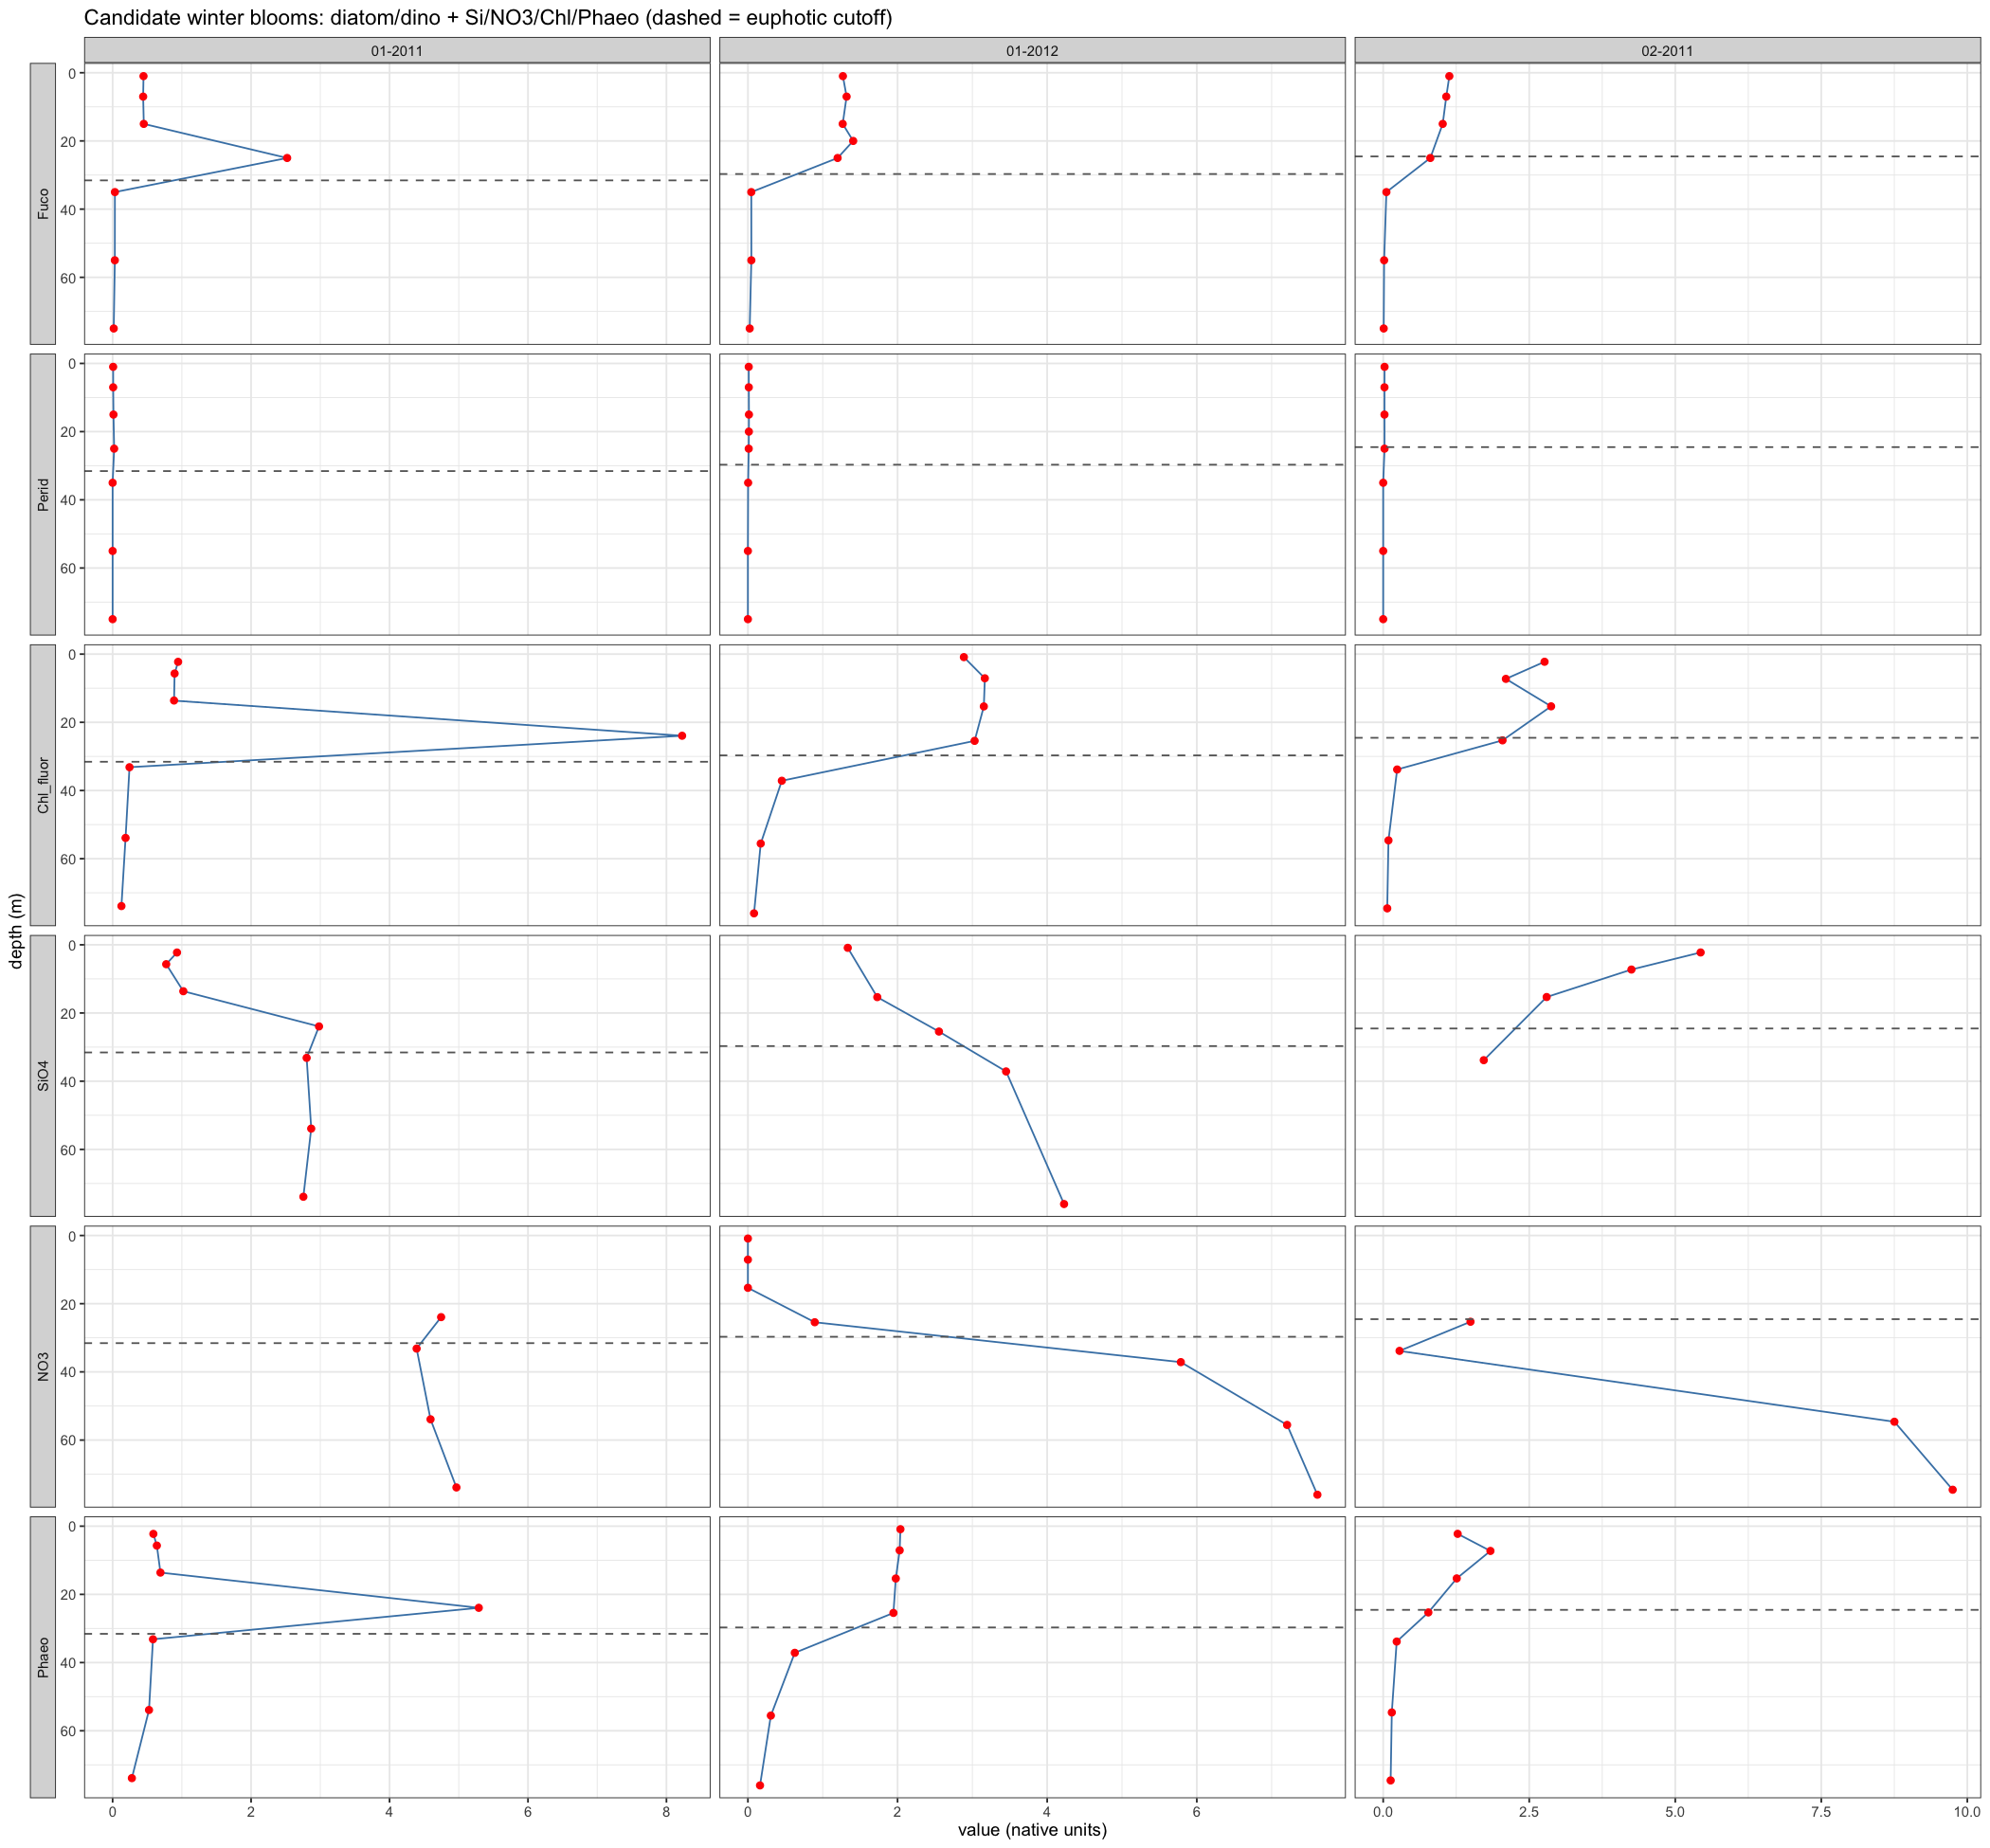

In [23]:
library(tidyverse)
cand <- c("01-2011","02-2011","01-2012")
euz <- read.csv("../processed/cariaco_monthly_euphotic_dynamic.csv") %>%
  mutate(time_month=format(as.Date(date),"%m-%Y")) %>% filter(time_month %in% cand) %>%
  transmute(time_month, depth_cutoff)

hp <- Mesh_HPLC %>% mutate(time_month=format(date,"%m-%Y")) %>% filter(time_month %in% cand) %>%
  select(time_month, depth, Fuco, Perid) %>% pivot_longer(c(Fuco,Perid), names_to="variable", values_to="value")
nk <- readRDS("../processed/Niskin_cleaned.rds") %>% mutate(time_month=format(date,"%m-%Y")) %>%
  filter(time_month %in% cand) %>%
  transmute(time_month, depth, SiO4=SiO4_merged, NO3=NO3_merged, Chl_fluor=Chlorophyll, Phaeo=Phaeopigments) %>%
  pivot_longer(c(SiO4,NO3,Chl_fluor,Phaeo), names_to="variable", values_to="value")

prof <- bind_rows(hp,nk) %>% filter(!is.na(value), depth<=80) %>%
  mutate(variable=factor(variable, levels=c("Fuco","Perid","Chl_fluor","SiO4","NO3","Phaeo")),
         time_month=factor(time_month, levels=cand))
print(ggplot(prof, aes(value, depth)) +
  geom_path(aes(group=time_month), colour="steelblue") + geom_point(colour="red", size=1.4) +
  geom_hline(data=euz, aes(yintercept=depth_cutoff), linetype="dashed", colour="grey40") +
  scale_y_reverse() + facet_grid(variable ~ time_month, scales="free_x", switch="y") +
  labs(x="value (native units)", y="depth (m)",
       title="Candidate winter blooms: diatom/dino + Si/NO3/Chl/Phaeo (dashed = euphotic cutoff)") +
  theme_bw(base_size=9) + theme(strip.placement="outside"))

cat("=== euphotic-mean per variable + key ratios (diatom & Si signatures) ===\n")
bind_rows(hp,nk) %>% left_join(euz, by="time_month") %>% filter(!is.na(value)) %>%
  group_by(time_month, variable) %>%
  summarise(euz_mean=mean(value[depth<=first(depth_cutoff)], na.rm=TRUE), .groups="drop") %>%
  pivot_wider(names_from=variable, values_from=euz_mean) %>%
  mutate(SiN=round(SiO4/NO3,2), FucoPerid=round(Fuco/Perid,1)) %>%
  as.data.frame() %>% print(row.names=FALSE)

In [24]:
library(tidyverse)
m <- read.csv("../processed/cariaco_monthly_euphotic_dynamic.csv") %>%
  mutate(date=as.Date(date), yr=as.integer(format(date,"%Y")), mo=as.integer(format(date,"%m")),
         time_month=format(date,"%m-%Y"),
         era=ifelse(yr<2005,"pre",ifelse(yr<2014,"post","recovery")),
         sumP=micro_mmolN+nano_mmolN+pico_mmolN)
cand <- c("01-2011","02-2011","01-2012")
post <- m %>% filter(era=="post", !is.na(Chl_niskin_mgm3))

cat(sprintf("POST niskin fluor chl (euphotic-mean, mg m-3): median=%.2f  p75=%.2f  p90=%.2f  max=%.2f  n=%d\n",
  median(post$Chl_niskin_mgm3), quantile(post$Chl_niskin_mgm3,.75), quantile(post$Chl_niskin_mgm3,.90),
  max(post$Chl_niskin_mgm3), nrow(post)))

cat("\n=== candidate months: fluor chl, post-era percentile, vs HPLC sumP ===\n")
post %>% mutate(fluor_pctile=round(100*rank(Chl_niskin_mgm3)/n())) %>%
  filter(time_month %in% cand) %>%
  transmute(time_month, Chl_fluor=round(Chl_niskin_mgm3,2), fluor_pctile, sumP_HPLC=round(sumP,2)) %>%
  arrange(desc(Chl_fluor)) %>% as.data.frame() %>% print(row.names=FALSE)

cat("\n=== post seasonal climatology of fluor chl (does winter stand out?) ===\n")
post %>% group_by(mo) %>% summarise(n=n(), chl_mean=round(mean(Chl_niskin_mgm3),2),
            chl_med=round(median(Chl_niskin_mgm3),2), .groups="drop") %>%
  as.data.frame() %>% print(row.names=FALSE)

cat(sprintf("\nfluor-chl vs HPLC sumP rank-agreement (post Spearman) = %.2f (n=%d)\n",
  cor(post$Chl_niskin_mgm3, post$sumP, method="spearman", use="complete.obs"),
  sum(!is.na(post$sumP))))

POST niskin fluor chl (euphotic-mean, mg m-3): median=0.29  p75=0.46  p90=0.84  max=4.72  n=89

=== candidate months: fluor chl, post-era percentile, vs HPLC sumP ===
 time_month Chl_fluor fluor_pctile sumP_HPLC
    01-2012      3.05           98      1.82
    01-2011      2.95           97      1.79
    02-2011      2.58           96      1.52

=== post seasonal climatology of fluor chl (does winter stand out?) ===
 mo n chl_mean chl_med
  1 6     1.58    1.22
  2 6     1.79    1.62
  3 8     1.09    0.51
  4 9     0.47    0.42
  5 9     0.32    0.26
  6 8     0.22    0.19
  7 8     0.30    0.28
  8 8     0.31    0.24
  9 8     0.22    0.22
 10 8     0.30    0.25
 11 5     0.16    0.16
 12 6     0.27    0.28

fluor-chl vs HPLC sumP rank-agreement (post Spearman) = 0.81 (n=64)


In [25]:
library(tidyverse)
m <- read.csv("../processed/cariaco_monthly_euphotic_dynamic.csv") %>%
  mutate(date=as.Date(date), yr=as.integer(format(date,"%Y")), mo=as.integer(format(date,"%m")),
         time_month=format(date,"%m-%Y"), era=ifelse(yr<2005,"pre",ifelse(yr<2014,"post","recovery")))
cand <- c("01-2011","02-2011","01-2012"); post <- m %>% filter(era=="post")

cat("=== candidate bloom months: is PP high, and is it even measured? ===\n")
post %>% filter(time_month %in% cand) %>%
  transmute(time_month, PP_mgC_m2_d=round(PP_mgC_m2_d), FN=round(FN_mmolN_m2_d,2),
            micro=round(micro_frac,2), Chl_fluor=round(Chl_niskin_mgm3,2),
            PP_present=!is.na(PP_mgC_m2_d)) %>% as.data.frame() %>% print(row.names=FALSE)

cat("\n=== all POST Jan/Feb cruises: PP, F_N, micro (NA = PP not measured) ===\n")
post %>% filter(mo %in% 1:2) %>% arrange(mo, time_month) %>%
  transmute(time_month, mo, PP_mgC_m2_d=round(PP_mgC_m2_d), FN=round(FN_mmolN_m2_d,2),
            micro=round(micro_frac,2)) %>% as.data.frame() %>% print(row.names=FALSE)

cat("\n=== POST monthly PP climatology (areal) — does Jan or Feb actually have higher PP? ===\n")
post %>% group_by(mo) %>% summarise(n_PP=sum(!is.na(PP_mgC_m2_d)),
            PP_mean=round(mean(PP_mgC_m2_d,na.rm=TRUE)), PP_med=round(median(PP_mgC_m2_d,na.rm=TRUE)),
            .groups="drop") %>% as.data.frame() %>% print(row.names=FALSE)

ppd <- post %>% filter(!is.na(PP_mgC_m2_d))
cat(sprintf("\nPOST PP (mgC m-2 d-1): median=%d  p90=%d  max=%d  n=%d\n",
  round(median(ppd$PP_mgC_m2_d)), round(quantile(ppd$PP_mgC_m2_d,.9)), round(max(ppd$PP_mgC_m2_d)), nrow(ppd)))
post %>% filter(time_month %in% cand, !is.na(PP_mgC_m2_d)) %>%
  mutate(PP_pctile=round(100*sapply(PP_mgC_m2_d, function(x) mean(ppd$PP_mgC_m2_d<=x)))) %>%
  transmute(time_month, PP_mgC_m2_d=round(PP_mgC_m2_d), PP_pctile) %>% as.data.frame() %>% print(row.names=FALSE)

=== candidate bloom months: is PP high, and is it even measured? ===
 time_month PP_mgC_m2_d   FN micro Chl_fluor PP_present
    01-2011          NA   NA  0.91      2.95      FALSE
    02-2011        1591 3.69  0.94      2.58       TRUE
    01-2012        2197 4.92  0.95      3.05       TRUE

=== all POST Jan/Feb cruises: PP, F_N, micro (NA = PP not measured) ===
 time_month mo PP_mgC_m2_d   FN micro
    01-2005  1        1148 2.49    NA
    01-2006  1        1176 2.76    NA
    01-2007  1          NA   NA    NA
    01-2008  1         710 1.47  0.62
    01-2009  1        1867 4.04  0.81
    01-2010  1          NA   NA    NA
    01-2011  1          NA   NA  0.91
    01-2012  1        2197 4.92  0.95
    01-2013  1          NA   NA    NA
    02-2005  2          NA   NA    NA
    02-2006  2        2785 6.87    NA
    02-2007  2        2982 7.79    NA
    02-2008  2        1531 3.51  0.26
    02-2009  2        1200   NA  0.56
    02-2010  2          NA   NA    NA
    02-2011  2        1591

In [26]:
library(tidyverse)
m <- read.csv("../processed/cariaco_monthly_euphotic_dynamic.csv") %>%
  mutate(date=as.Date(date), yr=as.integer(format(date,"%Y")), mo=as.integer(format(date,"%m")),
         time_month=format(date,"%m-%Y"),
         sumP=micro_mmolN+nano_mmolN+pico_mmolN, mcs=10^size_centroid,
         forcing_complete = !is.na(FN_mmolN_m2_d) & !is.na(depth_cutoff) & !is.na(Temp_C))
cat("=== POST Jan/Feb: shown in comparison = forcing_complete & has ΣP ===\n")
m %>% filter(yr>=2005, yr<2014, mo %in% 1:2) %>% arrange(mo, time_month) %>%
  transmute(time_month, FN=round(FN_mmolN_m2_d,2), Temp=round(Temp_C,1), d_e=round(depth_cutoff,1),
            micro=round(micro_frac,2), mcs=round(mcs,1), sumP=round(sumP,2),
            SHOWN = forcing_complete & !is.na(sumP)) %>% as.data.frame() %>% print(row.names=FALSE)

=== POST Jan/Feb: shown in comparison = forcing_complete & has ΣP ===
 time_month   FN Temp  d_e micro  mcs sumP SHOWN
    01-2005 2.49 24.6 41.0    NA   NA   NA FALSE
    01-2006 2.76 23.7 37.3    NA   NA   NA FALSE
    01-2007   NA   NA   NA    NA   NA   NA FALSE
    01-2008 1.47 24.8 48.5  0.62  7.8 0.37  TRUE
    01-2009 4.04 24.8 29.5  0.81 18.1 1.07  TRUE
    01-2010   NA   NA   NA    NA   NA   NA FALSE
    01-2011   NA 24.9 31.6  0.91 33.9 1.79 FALSE
    01-2012 4.92 24.4 29.7  0.95 44.7 1.82  TRUE
    01-2013   NA   NA   NA    NA   NA   NA FALSE
    02-2005   NA   NA   NA    NA   NA   NA FALSE
    02-2006 6.87 23.4 29.4    NA   NA   NA FALSE
    02-2007 7.79 22.7 23.7    NA   NA   NA FALSE
    02-2008 3.51 24.1 36.2  0.26  2.8 1.05  TRUE
    02-2009   NA   NA 47.0  0.56  4.1 0.61 FALSE
    02-2010   NA   NA   NA    NA   NA   NA FALSE
    02-2011 3.69 24.0 24.5  0.94 42.7 1.52  TRUE
    02-2012 2.15 22.4 40.2    NA   NA   NA FALSE
    02-2013   NA   NA   NA    NA   NA   NA FALSE

In [27]:
library(tidyverse)
files <- c("hplc_bbrs.csv","hplc_mote.csv","hplc_hpl.csv","hplc_ngsfc.csv")
map_dfr(files, ~read.csv(file.path("../BCO-DMO", .x))["Date"]) %>%
  mutate(date=as.Date(as.character(Date),"%Y%m%d")) %>% distinct(date) %>%
  mutate(yr=as.integer(format(date,"%Y")), mo=as.integer(format(date,"%m"))) %>%
  filter(yr>=2005, yr<2014, mo %in% 1:2) %>% arrange(date) %>%
  transmute(date, day=as.integer(format(date,"%d")), doy=as.integer(format(date,"%j"))) %>%
  as.data.frame() %>% print(row.names=FALSE)

       date day doy
 2007-02-05   5  36
 2008-01-10  10  10
 2008-02-12  12  43
 2009-01-13  13  13
 2009-02-10  10  41
 2010-01-07   7   7
 2010-02-11  11  42
 2011-01-11  11  11
 2011-02-08   8  39
 2012-01-10  10  10
 2012-02-07   7  38
